<a href="https://colab.research.google.com/github/VivekAChawla/camm_hackathon/blob/k4my4r/CAMM_Hackathon_2_Vivek.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 align="center">CAMM Hackathon - Session 1</h1>
<p align="left"><em>26 September 2025</em></p>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/KBForgeX/camm_hackathon/blob/k4my4r/docs/regressors/CAMM_Hackathon_1.ipynb)




**Data provenance** : The dataset aggregates measurements from a Dy–Er–Gd–Ho oxide wafer study in the CAMM by the Rack and Page groups


<h3>Goal: Feature → Target Prediction</h3>


This notebook hands you a **clean, standardized dataset** and a minimal prep pipeline so you can build your own predictive models. Your goal is to use the provided **features** (materials/structure descriptors) to **predict a target property** (default: *Thermal Conductivity*). The notebook **stops at data preparation**—you will implement and compare models (e.g., linear models, trees, neural nets) using the prepared data.

**What you’ll find here**
- A tidy table with `x`, `y` wafer coordinates and a set of engineered features (numeric, aligned to the same grid, with units harmonized).
- A simple example showing how to **select a target and features**, coerce to numeric, handle missing values (median imputation), and standardize inputs—ready for modeling.
- You can swap the target and feature lists to explore different prediction tasks.

**What you will do**
- Choose a **target** (e.g., `Thermal Conductivity`) and a subset of **features** you think are predictive.
- Train any models you like (sklearn, PyTorch, etc.) on the **prepared arrays**.
- Report basic metrics (RMSE, MAE, $R^2$) and, if useful, visualize predictions on the wafer grid using `x`, `y`.


#Data Preparation

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [3]:
!gdown --fuzzy https://drive.google.com/file/d/1BSZ3YyTw6dqELnL9qpfV8V5wVrbA-BPz/view?usp=sharing

Downloading...
From: https://drive.google.com/uc?id=1BSZ3YyTw6dqELnL9qpfV8V5wVrbA-BPz
To: /content/ReZrO_data.csv
100% 513k/513k [00:00<00:00, 11.4MB/s]


In [4]:
path = "/content/ReZrO_data.csv"   # update if path differs
df = pd.read_csv(path)

Let's see what all properties we have in the dataset

In [5]:
print("Dataframe shape:", df.shape)
display(df.head())


Dataframe shape: (2601, 17)


,x,y,Thermal Conductivity,Lattice Parameter(WPF),delta_d(SPF-WPF),d-spacing(WPF),Fluorite Size Disorder,Entropy,strain(LMFIT-dspacing),a111(LMFIT),a200(LMFIT),mismatch(LMFIT-lattice parameter),d111(LMFIT),d200(LMFIT),corr_length,fwhm111(LMFIT),delta_d/d
0,-2.5,-2.5,0.668247,5.245110,0.020399,2.622555,0.103832,3.924187,0.127131,5.245331,5.286782,-0.007902,3.028393,2.643391,2.94866,0.097076,0.007778
1,-2.5,-2.4,0.651635,5.245110,0.020399,2.622555,0.103727,3.927794,0.127131,5.245331,5.286782,-0.007902,3.028393,2.643391,2.94866,0.097076,0.007778
2,-2.5,-2.3,0.661063,5.244901,0.019877,2.622450,0.103588,3.939862,0.127240,5.245438,5.286226,-0.007776,3.028455,2.643113,2.94866,0.096367,0.007580
3,-2.5,-2.2,0.594712,5.244901,0.019877,2.622450,0.103447,3.951859,0.127240,5.245438,5.286226,-0.007776,3.028455,2.643113,2.94866,0.096367,0.007580
4,-2.5,-2.1,0.620809,5.244680,0.019664,2.622340,0.103338,3.955091,0.127249,5.245217,5.285954,-0.007766,3.028328,2.642977,2.94866,0.095942,0.007499


Let's plot them and see how they look

### Feature Definitions

1. **Lattice Parameter (WPF)**  
   Calculated by fitting the **whole XRD spectrum** using **TOPAS**.

2. **d-spacing (WPF)**  
   Average d-spacing calculated from fitting all peaks.

3. **Δd (SPF–WPF)**  
   Difference between *d-spacing (200 peak)* (2nd XRD peak) and *d-spacing (WPF)*:  
   $$ \Delta d = d_{WPF} - d_{\text{SPF}} $$

4. **delta_d/d**  
   Strain calculated from (2) and (3):  
   $$ \frac{\Delta d}{d} = \frac{d_{WPF} - d_{\text{SPF}}}{d_{\text{WPF}}} $$

5. **a111 (LMFit)**  
   Lattice parameter from fitting the **111 peak** (1st XRD peak) using the **LMFit** package.

6. **a200 (LMFit)**  
   Lattice parameter from fitting the **200 peak** (2nd XRD peak) using **LMFit**.

7. **Mismatch (LMFit – lattice parameter)**  
   $$ \text{Mismatch} = \frac{a_{111} - a_{200}}{a_{111}} $$

8. **d111 (LMFit)**  
   d-spacing of the 111 peak from LMFit.

9. **d200 (LMFit)**  
   d-spacing of the 200 peak from LMFit.

10. **Correlation Length**  
    Calculated from AFM images.

11. **FWHM111 (LMFit)**  
    Full Width at Half Maximum of the **111 peak**.

12. **Strain (LMFit – d-spacing)**  
    Strain calculated using LMFit d-spacing values:  
    $$ \frac{\Delta d}{d}{LMFIT} = \frac{d_{111} - d_{200}}{d_{111}} $$


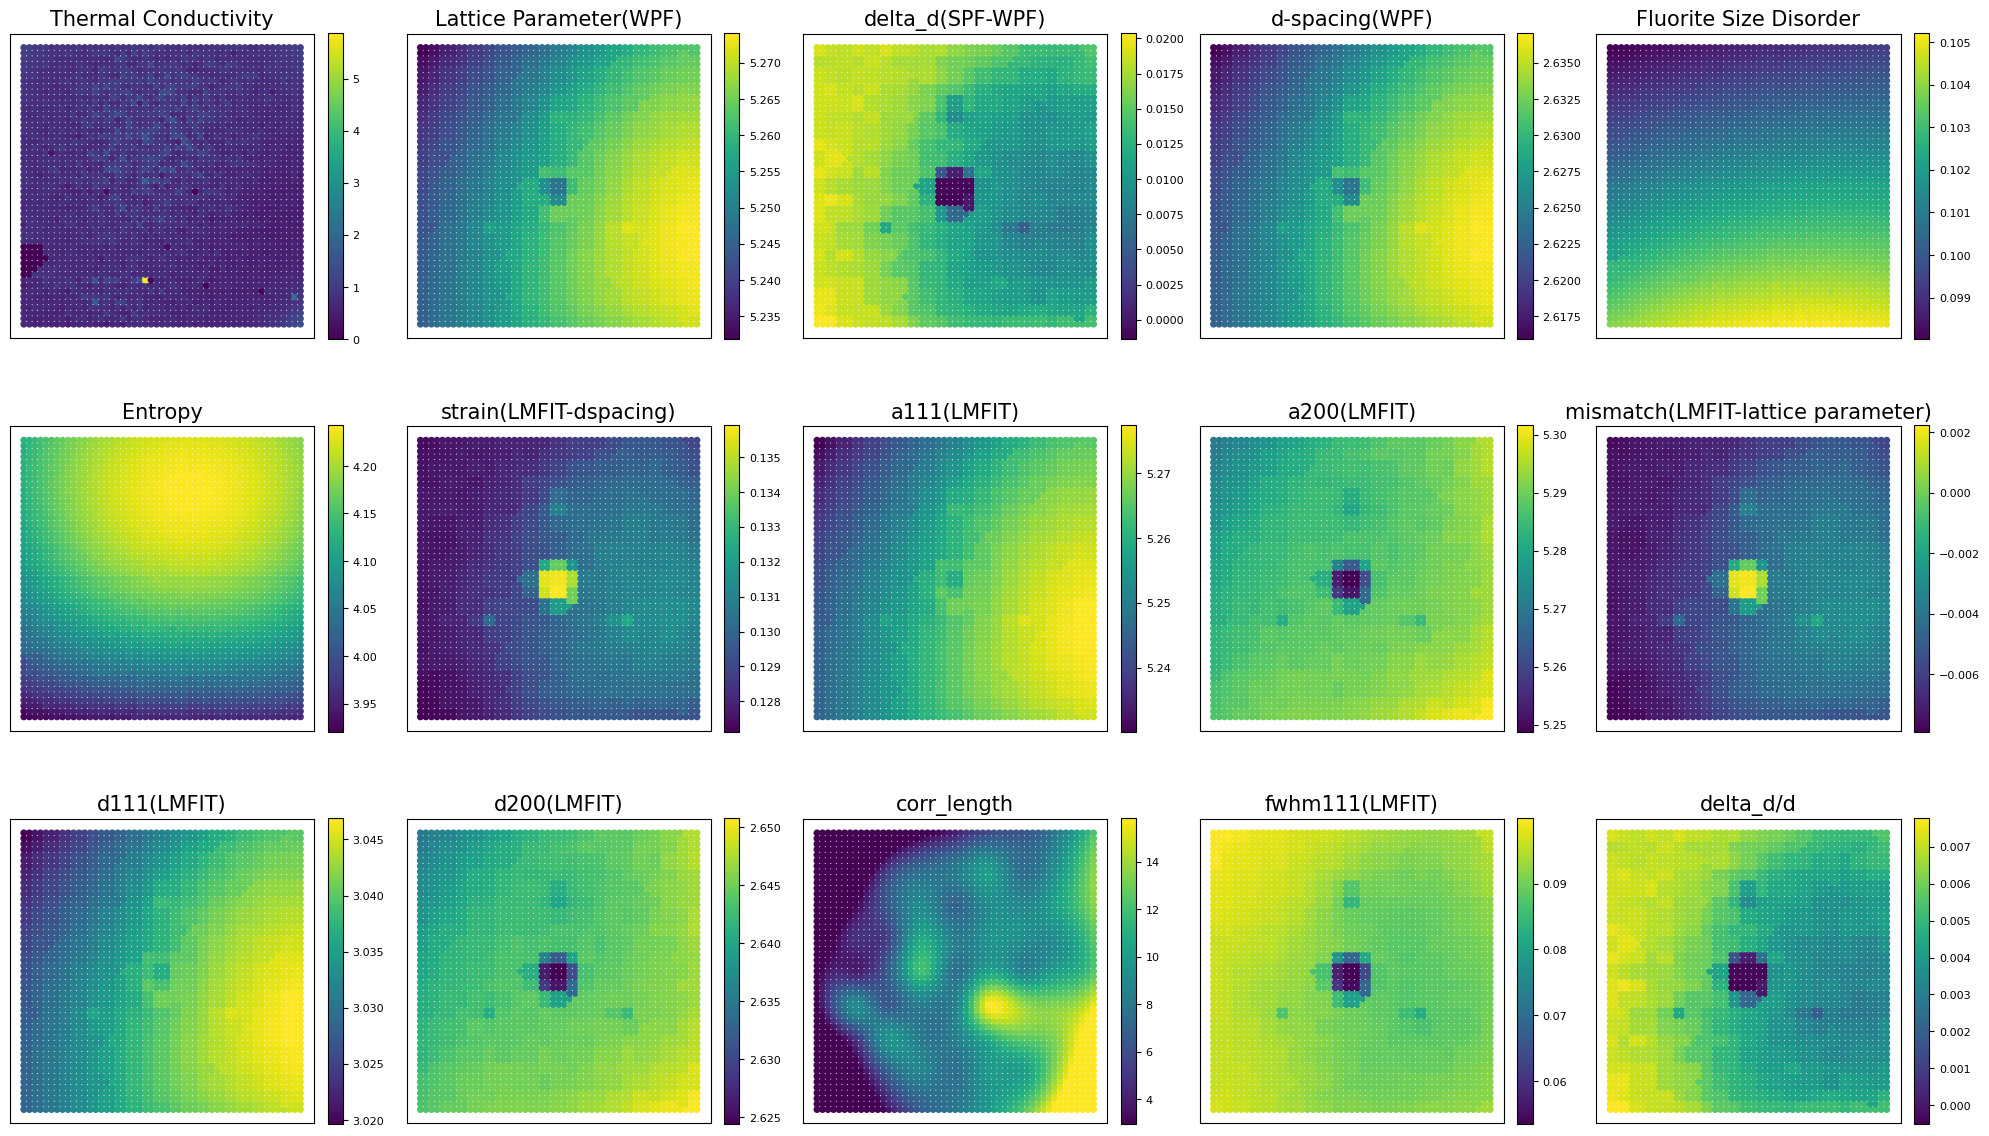

In [6]:
x = df["x"].to_numpy()
y = df["y"].to_numpy()

feature_cols = [c for c in df.columns if c not in ["x", "y"]]

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for ax, col in zip(axes, feature_cols):
    z = pd.to_numeric(df[col], errors="coerce").to_numpy()
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)

    sc = ax.scatter(x[mask], y[mask], c=z[mask], s=16, cmap="viridis")
    ax.set_title(col, fontsize=15)
    ax.set_aspect("equal", "box")
    ax.set_xticks([]); ax.set_yticks([])

    # colorbar for each subplot
    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)

# Hide any unused subplots
for ax in axes[len(feature_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

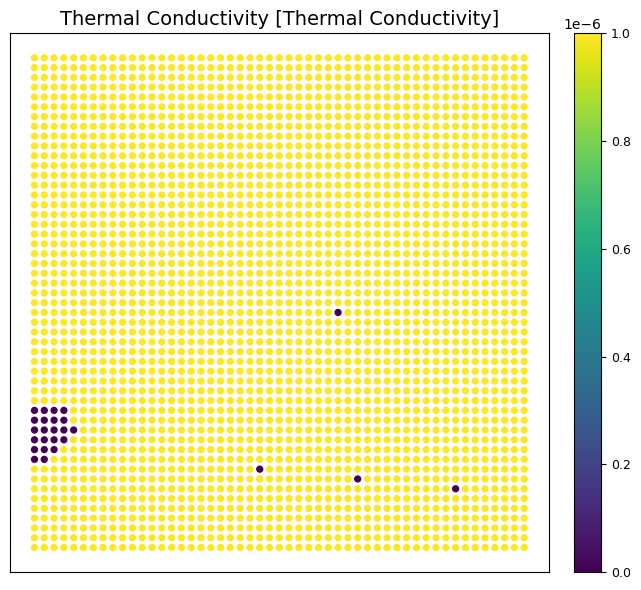

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- set the column explicitly ---
z_col = "Thermal Conductivity"   # exact match from your df.columns

# --- data ---
x = pd.to_numeric(df["x"], errors="coerce").to_numpy()
y = pd.to_numeric(df["y"], errors="coerce").to_numpy()
z = pd.to_numeric(df[z_col], errors="coerce").to_numpy()
mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)

# --- plot ---
plt.figure(figsize=(7, 6))# use them in your scatter
sc = plt.scatter(x[mask], y[mask], c=z[mask], s=18, cmap="viridis", vmin=0, vmax=0.000001)
plt.title(f"Thermal Conductivity [{z_col}]", fontsize=14)
plt.gca().set_aspect("equal", "box")
plt.xticks([]); plt.yticks([])
# plt.gca().invert_yaxis()  # uncomment if your y should increase downward
cbar = plt.colorbar(sc, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()


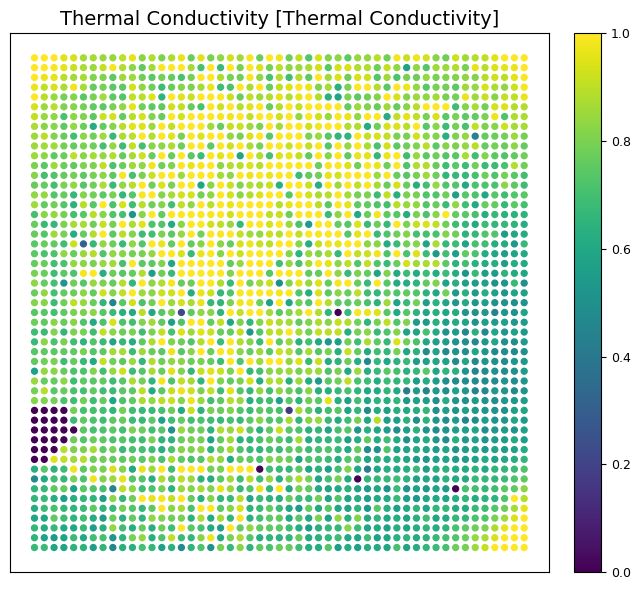

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- set the column explicitly ---
z_col = "Thermal Conductivity"   # exact match from your df.columns

# --- data ---
x = pd.to_numeric(df["x"], errors="coerce").to_numpy()
y = pd.to_numeric(df["y"], errors="coerce").to_numpy()
z = pd.to_numeric(df[z_col], errors="coerce").to_numpy()
mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)

# --- plot ---
plt.figure(figsize=(7, 6))# use them in your scatter
sc = plt.scatter(x[mask], y[mask], c=z[mask], s=18, cmap="viridis", vmin=0, vmax=1
)
plt.title(f"Thermal Conductivity [{z_col}]", fontsize=14)
plt.gca().set_aspect("equal", "box")
plt.xticks([]); plt.yticks([])
# plt.gca().invert_yaxis()  # uncomment if your y should increase downward
cbar = plt.colorbar(sc, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()


In [9]:
df.columns

Index(['x', 'y', 'Thermal Conductivity', 'Lattice Parameter(WPF)',
       'delta_d(SPF-WPF)', 'd-spacing(WPF)', 'Fluorite Size Disorder',
       'Entropy', 'strain(LMFIT-dspacing)', 'a111(LMFIT)', 'a200(LMFIT)',
       'mismatch(LMFIT-lattice parameter)', 'd111(LMFIT)', 'd200(LMFIT)',
       'corr_length', 'fwhm111(LMFIT)', 'delta_d/d'],
      dtype='object')

# How to use this to train in networks?

In [10]:
features = [
    'a111(LMFIT)', 'mismatch(LMFIT-lattice parameter)',
    'Fluorite Size Disorder', 'Entropy',
    'corr_length',
]
target = 'Thermal Conductivity'

missing = [c for c in features + [target] if c not in df.columns]
if missing:
    raise KeyError(f"These columns are missing in df: {missing}")

In [11]:
for c in features + [target]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 3) drop rows with missing target
df_clean = df.dropna(subset=[target]).copy()

# 4) build matrices
X_raw = df_clean[features].to_numpy(dtype=np.float32) # Input features
y_raw = df_clean[target].to_numpy(dtype=np.float32)[:, None] #Target feature that needs to be predicted
XY    = df_clean[["x","y"]].to_numpy(dtype=np.float32) if set(["x","y"]).issubset(df_clean.columns) else None # can be used to plot predictions back on the grid


In [12]:
X_train_raw, X_val_raw, y_train, y_val, XY_train, XY_val = train_test_split(
    X_raw, y_raw, XY, test_size=0.2, random_state=42
)
# Use this to split into training and testing dataset

We split the dataset into training and test sets because we want to test our model on unseen data

## Build your network now

Make use of Chatgpt and build your own network to predict one of the features you select

# Building Genetic regressor- Simple

In [13]:
# genetic_symbolic_regression.py
# Minimal genetic programming for symbolic regression
# Ops: +, -, *, /, exp, log, sin, cos
# Demo target: y = exp(2x) (with noisy train samples)

import math
import random
from typing import Tuple, List
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# 1) Expression representation
#    Node types (nested tuples):
#       ("const", value)
#       ("var", idx)                  # x[idx], here we will use idx=0 (single variable)
#       ("op", "opname", left, right) # binary ops
#       ("uop", "opname", child)      # unary ops
# ------------------------------

BINARY_OPS = ("+", "-", "*", "/")
UNARY_OPS  = ("exp", "log", "sin", "cos")

def safe_div(a, b):
    return a / (b + 1e-8)

def safe_log(a):
    return np.log(np.abs(a) + 1e-8)

OP_TABLE = {
    "+": lambda a,b: a + b,
    "-": lambda a,b: a - b,
    "*": lambda a,b: a * b,
    "/": safe_div,
}
UOP_TABLE = {
    "exp": np.exp,
    "log": safe_log,
    "sin": np.sin,
    "cos": np.cos,
}

def random_const():
    # bias toward useful small constants to speed up convergence
    choices = [0.5, 1.0, 2.0, 3.0, math.e, math.pi]
    if random.random() < 0.6:
        return ("const", random.choice(choices))
    return ("const", random.uniform(-3.0, 3.0))

def random_var(n_vars=1):
    # choose which x[idx] to use (supports multivariate if you set n_vars>1)
    return ("var", random.randrange(n_vars))

def random_leaf(n_vars=1):
    return random_var(n_vars) if random.random() < 0.5 else random_const()

def random_tree(max_depth: int, n_vars=1):
    if max_depth == 0 or random.random() < 0.35:
        return random_leaf(n_vars)
    if random.random() < 0.5:
        op = random.choice(BINARY_OPS)
        return ("op", op,
                random_tree(max_depth-1, n_vars),
                random_tree(max_depth-1, n_vars))
    else:
        op = random.choice(UNARY_OPS)
        return ("uop", op, random_tree(max_depth-1, n_vars))

def tree_size(t) -> int:
    tag = t[0]
    if tag in ("const", "var"):
        return 1
    if tag == "op":
        return 1 + tree_size(t[2]) + tree_size(t[3])
    if tag == "uop":
        return 1 + tree_size(t[2])
    raise ValueError("Bad node")

def eval_tree(t, X: np.ndarray) -> np.ndarray:
    """Evaluate tree on X of shape (N, D)."""
    tag = t[0]
    if tag == "const":
        return np.full(X.shape[0], float(t[1]), dtype=float)
    if tag == "var":
        idx = int(t[1])
        return X[:, idx]
    if tag == "op":
        f = OP_TABLE[t[1]]
        return f(eval_tree(t[2], X), eval_tree(t[3], X))
    if tag == "uop":
        f = UOP_TABLE[t[1]]
        return f(eval_tree(t[2], X))
    raise ValueError("Bad node")

def serialize(t) -> str:
    tag = t[0]
    if tag == "const":
        v = float(t[1])
        if abs(v - round(v)) < 1e-12:
            return str(int(round(v)))
        return f"{v:.6g}"
    if tag == "var":
        return f"x{t[1]}"
    if tag == "op":
        return f"({serialize(t[2])} {t[1]} {serialize(t[3])})"
    if tag == "uop":
        return f"{t[1]}({serialize(t[2])})"
    raise ValueError("Bad node")

# ------------------------------
# 2) Genetic operators
# ------------------------------

def mutate(t, max_depth=3, n_vars=1, p_change_const=0.5):
    # replace whole subtree sometimes
    if random.random() < 0.2:
        return random_tree(max_depth, n_vars)
    tag = t[0]
    if tag == "const":
        if random.random() < p_change_const:
            return random_const()
        return ("const", float(t[1]) + random.uniform(-0.5, 0.5))
    if tag == "var":
        # occasionally switch which variable
        if random.random() < 0.1 and n_vars > 1:
            return ("var", random.randrange(n_vars))
        return t
    if tag == "op":
        # possibly swap operator
        if random.random() < 0.2:
            return ("op", random.choice(BINARY_OPS), t[2], t[3])
        return ("op", t[1], mutate(t[2], max_depth, n_vars), mutate(t[3], max_depth, n_vars))
    if tag == "uop":
        if random.random() < 0.2:
            return ("uop", random.choice(UNARY_OPS), t[2])
        return ("uop", t[1], mutate(t[2], max_depth, n_vars))
    return t

def _enumerate_nodes(t, path=None, out=None):
    if path is None:
        path = []
    if out is None:
        out = []
    out.append((path, t))
    tag = t[0]
    if tag == "op":
        _enumerate_nodes(t[2], path + [2], out)
        _enumerate_nodes(t[3], path + [3], out)
    elif tag == "uop":
        _enumerate_nodes(t[2], path + [2], out)
    return out

def random_subtree(t):
    nodes = _enumerate_nodes(t)
    return random.choice(nodes)  # (path, node)

def set_subtree(t, path: List[int], new_sub):
    if not path:
        return new_sub
    head, rest = path[0], path[1:]
    tag = t[0]
    if tag == "op":
        if head == 2:
            return ("op", t[1], set_subtree(t[2], rest, new_sub), t[3])
        else:
            return ("op", t[1], t[2], set_subtree(t[3], rest, new_sub))
    if tag == "uop":
        return ("uop", t[1], set_subtree(t[2], rest, new_sub))
    return t

def crossover(a, b):
    path_a, _ = random_subtree(a)
    _, sub_b  = random_subtree(b)
    return set_subtree(a, path_a, sub_b)

# ------------------------------
# 3) Fitness & evolution
# ------------------------------

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred)**2)))

def fitness(t, X, y, alpha_size=1e-3):
    try:
        yp = eval_tree(t, X)
        if not np.all(np.isfinite(yp)) or np.any(np.abs(yp) > 1e6):
            return 1e9
        err = rmse(y, yp)
        comp = alpha_size * tree_size(t)   # complexity penalty keeps formulas small
        return err + comp
    except Exception:
        return 1e9

def evolve(
    X, y, n_vars=1, pop_size=200, generations=60,
    max_depth=4, elite_frac=0.05,
    p_mutate=0.6, p_crossover=0.35, tournament_k=4,
    rng_seed=0
):
    random.seed(rng_seed)
    pop = [random_tree(max_depth, n_vars) for _ in range(pop_size)]
    scores = [fitness(t, X, y) for t in pop]

    def tournament():
        cand = random.sample(range(pop_size), tournament_k)
        best_i = min(cand, key=lambda i: scores[i])
        return pop[best_i]

    history = []
    for _ in range(generations):
        scores = [fitness(t, X, y) for t in pop]
        order = np.argsort(scores)
        pop = [pop[i] for i in order]
        scores = [scores[i] for i in order]
        history.append(scores[0])

        next_pop = []
        elite_n = max(1, int(elite_frac * pop_size))
        next_pop.extend(pop[:elite_n])  # elitism

        while len(next_pop) < pop_size:
            r = random.random()
            if r < p_crossover:
                a, b = tournament(), tournament()
                child = crossover(a, b)
            elif r < p_crossover + p_mutate:
                a = tournament()
                child = mutate(a, max_depth=max_depth, n_vars=n_vars)
            else:
                child = random_tree(max_depth, n_vars)
            next_pop.append(child)
        pop = next_pop

    scores = [fitness(t, X, y) for t in pop]
    best_idx = int(np.argmin(scores))
    return pop[best_idx], float(scores[best_idx]), history




/tmp/ipython-input-2481395598.py:92: RuntimeWarning: overflow encountered in exp
  return f(eval_tree(t[2], X))
/tmp/ipython-input-2481395598.py:92: RuntimeWarning: invalid value encountered in sin
  return f(eval_tree(t[2], X))
/tmp/ipython-input-2481395598.py:92: RuntimeWarning: invalid value encountered in cos
  return f(eval_tree(t[2], X))


Best expression: exp((x0 / 0.5))


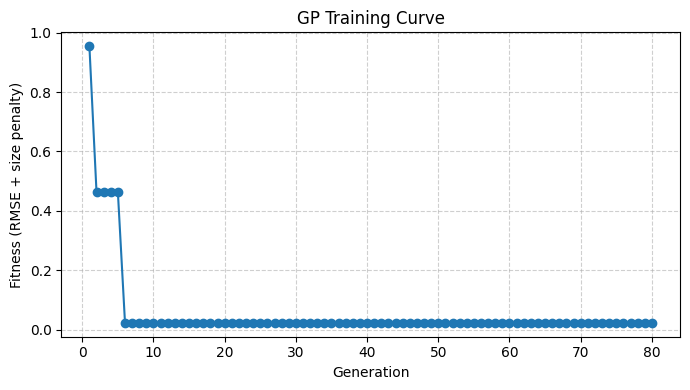

Train RMSE: 0.0188
Val RMSE vs exp(2x): 1.7255e-07


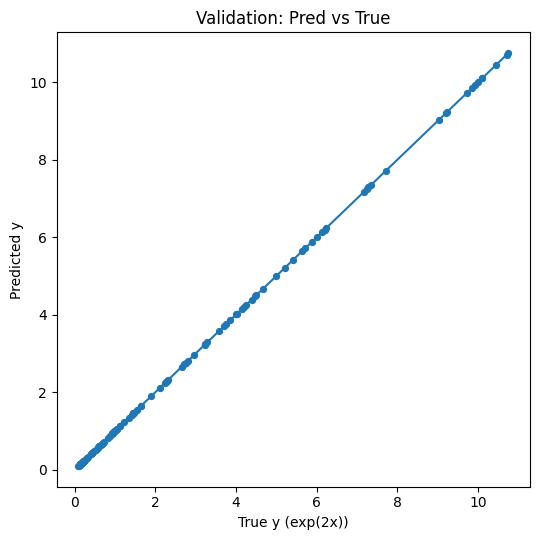

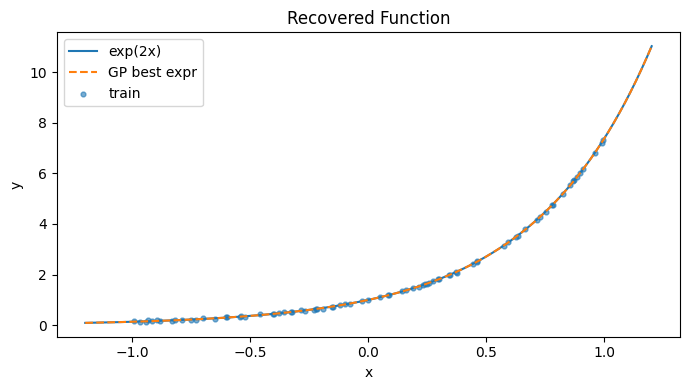

In [14]:
# ------------------------------
# 4) Demo: recover y = exp(2x)
# ------------------------------

if __name__ == "__main__":
    rng = np.random.default_rng(0)
    n_train, n_val = 80, 120
    x_train = rng.uniform(-1.0, 1.0, size=n_train)
    y_train = np.exp(2 * x_train) + rng.normal(0, 0.02, size=n_train)  # noisy train
    x_val   = rng.uniform(-1.2, 1.2, size=n_val)
    y_val   = np.exp(2 * x_val)  # clean val

    # GP expects X with shape (N, D); here D=1
    X_train = x_train.reshape(-1, 1)
    X_val   = x_val.reshape(-1, 1)

    best, best_score, hist = evolve(
        X_train, y_train,
        n_vars=1, pop_size=220, generations=80, max_depth=5, rng_seed=2
    )

    expr = serialize(best)
    print("Best expression:", expr)

    # Training curve
    plt.figure(figsize=(7,4))
    plt.plot(np.arange(1, len(hist)+1), hist, marker="o")
    plt.xlabel("Generation"); plt.ylabel("Fitness (RMSE + size penalty)")
    plt.title("GP Training Curve")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout(); plt.show()

    # Quality on train/val
    yhat_train = eval_tree(best, X_train)
    yhat_val   = eval_tree(best, X_val)
    tr_rmse = rmse(y_train, yhat_train)
    va_rmse = rmse(y_val, yhat_val)
    print(f"Train RMSE: {tr_rmse:.4f}")
    print(f"Val RMSE vs exp(2x): {va_rmse:.4e}")

    # Pred vs true (val)
    plt.figure(figsize=(5.5,5.5))
    plt.scatter(y_val, yhat_val, s=18)
    mn, mx = float(min(np.min(y_val), np.min(yhat_val))), float(max(np.max(y_val), np.max(yhat_val)))
    plt.plot([mn, mx], [mn, mx])
    plt.xlabel("True y (exp(2x))"); plt.ylabel("Predicted y")
    plt.title("Validation: Pred vs True")
    plt.tight_layout(); plt.show()

    # Function curves
    xs = np.linspace(-1.2, 1.2, 400).reshape(-1,1)
    plt.figure(figsize=(7,4))
    plt.plot(xs.ravel(), np.exp(2*xs).ravel(), label="exp(2x)")
    plt.plot(xs.ravel(), eval_tree(best, xs), "--", label="GP best expr")
    plt.scatter(x_train, y_train, s=12, alpha=0.6, label="train")
    plt.xlabel("x"); plt.ylabel("y"); plt.title("Recovered Function")
    plt.legend(); plt.tight_layout(); plt.show()

/tmp/ipython-input-2481395598.py:92: RuntimeWarning: overflow encountered in exp
  return f(eval_tree(t[2], X))
/tmp/ipython-input-2481395598.py:92: RuntimeWarning: invalid value encountered in cos
  return f(eval_tree(t[2], X))
/tmp/ipython-input-2481395598.py:92: RuntimeWarning: invalid value encountered in sin
  return f(eval_tree(t[2], X))


Best expression: (exp(x0) + exp((x0 + sin((sin((sin((sin(log((x0 * 2.71828))) + sin((x0 + (sin((sin((sin(log((x0 * 2.71828))) + x0)) + x0)) + sin(sin(x0))))))) + x0)) + sin(sin((x0 + sin((sin((x0 + x0)) + sin(log(((x0 * 2.71828) + x0)))))))))))))
Validation RMSE: 1.052960
Best fitness (train RMSE + size penalty): 0.439640
Generations run: 100


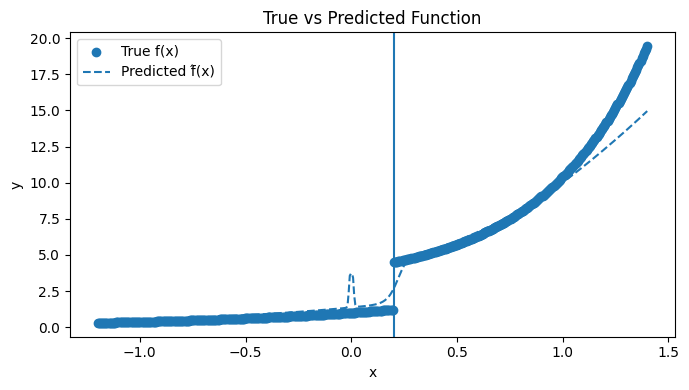

In [15]:
# --- Piecewise ground truth + call your existing GP (no plotting) ---
# Assumes you already defined: evolve, eval_tree, serialize, rmse  (from the earlier GP code)

import numpy as np

# 1) Ground truth with a regime jump:
#    y = exp(x)         for x <= x0
#    y = exp(2x) + JUMP for x >  x0
x0       = 0.2    # switch point
JUMP     = 3    # vertical jump
noise_sd = 0.03   # training noise level

def ground_truth(x):
    x = np.asarray(x, dtype=float)
    return np.where(x <= x0, np.exp(x), np.exp(2 * x) + JUMP)

# 2) Make training/validation data
rng = np.random.default_rng(123)
n_train, n_val = 140, 240

x_train = rng.uniform(-1.0, 1.2, size=n_train)
y_train = ground_truth(x_train) + rng.normal(0, noise_sd, size=n_train)

x_val = rng.uniform(-1.2, 1.4, size=n_val)
y_val = ground_truth(x_val)

X_train = x_train.reshape(-1, 1)
X_val   = x_val.reshape(-1, 1)

# 3) Evolve with your SAME GP (handles either rng_seed or seed arg)
gp_kwargs = dict(n_vars=1, pop_size=220, generations=100, max_depth=5)
try:
    best, best_score, hist = evolve(X_train, y_train, rng_seed=7, **gp_kwargs)
except TypeError:
    best, best_score, hist = evolve(X_train, y_train, seed=7, **gp_kwargs)

# 4) Evaluate (no figures)
expr = serialize(best)
yhat_val = eval_tree(best, X_val)
val_rmse = rmse(y_val, yhat_val)

print("Best expression:", expr)
print(f"Validation RMSE: {val_rmse:.6f}")
print(f"Best fitness (train RMSE + size penalty): {best_score:.6f}")
print(f"Generations run: {len(hist)}")


# --- Plot true vs predicted function (end of notebook) ---
import numpy as np
import matplotlib.pyplot as plt

# assumes you already have: best (tree), eval_tree(), ground_truth(), x0

xs = np.linspace(-1.2, 1.4, 500).reshape(-1, 1)
y_true = ground_truth(xs.ravel())
y_pred = eval_tree(best, xs)

plt.figure(figsize=(7, 4))
plt.scatter(xs.ravel(), y_true, label="True f(x)")
plt.plot(xs.ravel(), y_pred, "--", label="Predicted f̂(x)")
plt.axvline(x0)  # show the regime switch
plt.xlabel("x")
plt.ylabel("y")
plt.title("True vs Predicted Function")
plt.legend()
plt.tight_layout()
plt.show()



# Decision tree based Genetic Algorithm

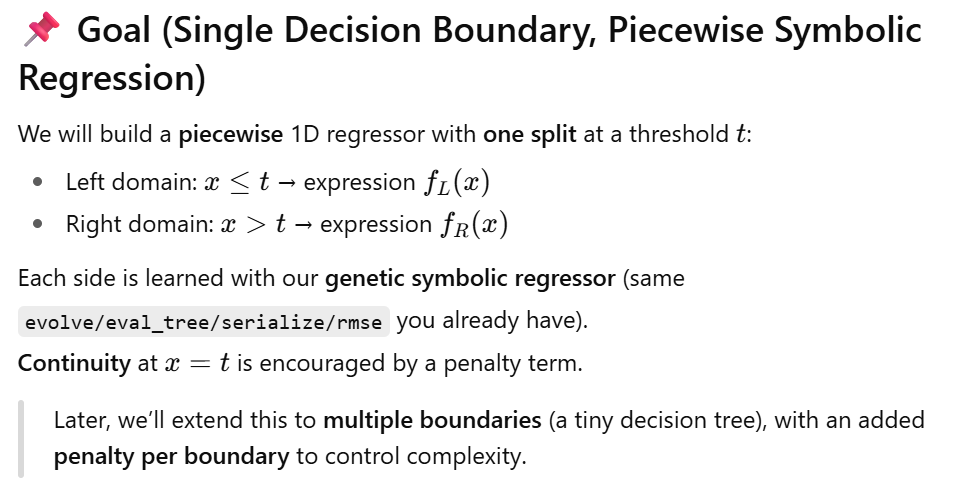

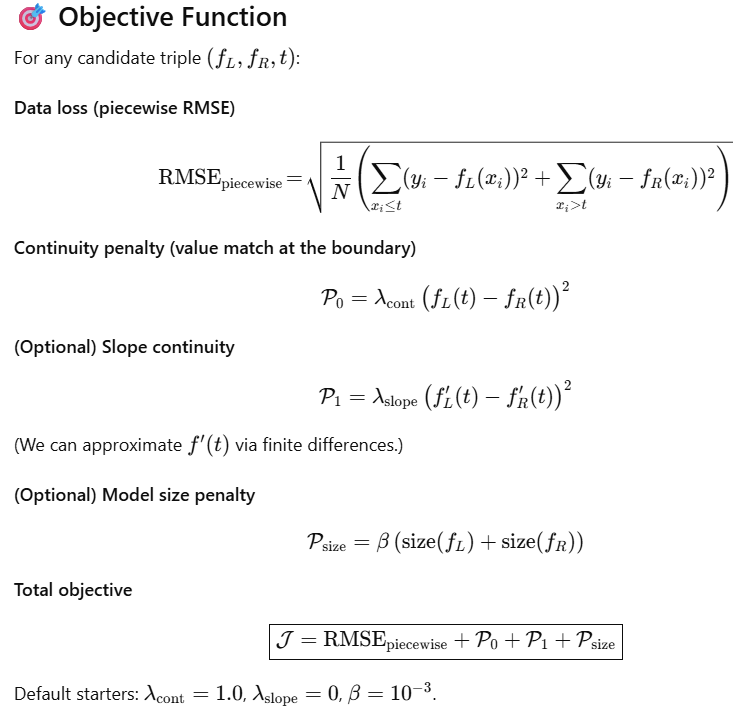

In [16]:
# ============================================================
# Piecewise symbolic regression with ONE decision boundary (genetic per side)
# - Reuses your GP: evolve(), eval_tree(), serialize(), rmse(), (optionally tree_size)
# - Searches for the best split t (decision boundary) and two expressions (left/right)
# - Objective = piecewise RMSE + lambda_cont * continuity_gap^2 (+ optional size penalty)
# ============================================================

import numpy as np

# ---------- Config ----------
LAMBDA_CONT = 1.0     # continuity penalty weight (start with 1.0)
BETA_SIZE   = 0.0     # set 0.0 now (no cost for decision boundary). Later: >0
USE_SLOPE_CONT = False
FD_EPS = 1e-4         # finite-difference step if slope continuity enabled

# GP hyperparams per-side (you can tweak)
GP_KW = dict(pop_size=200, generations=80, max_depth=5)
SEEDS_PER_SIDE = [2, 7, 11]  # try multiple seeds and keep best per side

# ---------- Utilities ----------
def _has_tree_size():
    try:
        _ = tree_size  # noqa: F821
        return True
    except NameError:
        return False

def _size_or_zero(tree):
    if _has_tree_size():
        return tree_size(tree)  # noqa: F821
    return 0

def _finite_diff_slope(tree, t):
    """Approximate f'(t) with central finite differences on scalar x."""
    Xp = np.array([[t + FD_EPS]], dtype=float)
    Xm = np.array([[t - FD_EPS]], dtype=float)
    yp = float(eval_tree(tree, Xp))  # noqa: F821
    ym = float(eval_tree(tree, Xm))  # noqa: F821
    return (yp - ym) / (2.0 * FD_EPS)

def _fit_side(X, y, mask, seeds, gp_kw):
    """Fit one side by trying multiple seeds; return (best_tree, best_rmse, best_seed)."""
    X_side, y_side = X[mask], y[mask]
    if X_side.shape[0] == 0:
        return None, np.inf, None

    best = None
    best_score = np.inf
    best_seed = None

    # Try multiple seeds; keep best by (RMSE + small size penalty to break ties)
    for sd in seeds:
        # evolve may accept rng_seed or seed depending on your earlier definition
        try:
            tree, score, _ = evolve(X_side, y_side, seed=sd, **gp_kw)  # noqa: F821
        except TypeError:
            tree, score, _ = evolve(X_side, y_side, rng_seed=sd, **gp_kw)  # noqa: F821

        y_hat = eval_tree(tree, X_side)  # noqa: F821
        side_rmse = rmse(y_side, y_hat)  # noqa: F821
        tie_break = 1e-6 * _size_or_zero(tree)
        this_score = side_rmse + tie_break
        if this_score < best_score:
            best_score = this_score
            best = tree
            best_seed = sd

    # Recompute pure RMSE for reporting
    y_hat = eval_tree(best, X_side)     # noqa: F821
    pure_rmse = rmse(y_side, y_hat)     # noqa: F821
    return best, pure_rmse, best_seed

def _objective_piecewise(left_tree, right_tree, t, X, y):
    """Compute total objective and components for a given pair and threshold."""
    x = X[:, 0]
    L = x <= t
    R = ~L
    if L.sum() == 0 or R.sum() == 0:
        return dict(obj=np.inf, rmse=np.inf, left_rmse=np.inf, right_rmse=np.inf,
                    gap=np.inf, slope_gap=np.inf, size_pen=0.0)

    # Per-side predictions and RMSE
    yL_hat = eval_tree(left_tree,  X[L])   # noqa: F821
    yR_hat = eval_tree(right_tree, X[R])   # noqa: F821
    left_rmse  = rmse(y[L], yL_hat)        # noqa: F821
    right_rmse = rmse(y[R], yR_hat)        # noqa: F821

    # Combine into overall RMSE
    N = float(len(y))
    piecewise_rmse = np.sqrt(((y[L] - yL_hat)**2).sum() + ((y[R] - yR_hat)**2).sum()) / np.sqrt(N)

    # Continuity penalty at boundary
    tX = np.array([[t]], dtype=float)
    fL_t = float(eval_tree(left_tree, tX))     # noqa: F821
    fR_t = float(eval_tree(right_tree, tX))    # noqa: F821
    gap = fL_t - fR_t
    cont_pen = LAMBDA_CONT * (gap * gap)

    # Optional slope continuity
    slope_pen = 0.0
    slope_gap_val = np.nan
    if USE_SLOPE_CONT:
        dL = _finite_diff_slope(left_tree, t)
        dR = _finite_diff_slope(right_tree, t)
        slope_gap_val = dL - dR
        slope_pen = LAMBDA_CONT * (slope_gap_val * slope_gap_val)

    # Optional size penalty (currently 0.0 by default)
    size_pen = BETA_SIZE * (_size_or_zero(left_tree) + _size_or_zero(right_tree))

    total = piecewise_rmse + cont_pen + slope_pen + size_pen
    return dict(
        obj=total, rmse=piecewise_rmse,
        left_rmse=left_rmse, right_rmse=right_rmse,
        gap=gap, slope_gap=slope_gap_val,
        size_pen=size_pen
    )

def build_threshold_candidates(X, q_lo=0.1, q_hi=0.9, num=17):
    """Quantile-based candidate thresholds between q_lo and q_hi."""
    xs = np.sort(X[:, 0])
    qs = np.linspace(q_lo, q_hi, num=num)
    t_list = np.quantile(xs, qs)
    # ensure uniqueness and numeric
    t_list = np.unique(np.asarray(t_list, dtype=float))
    return t_list

def piecewise_search(
    X, y, t_candidates=None,
    seeds_per_side=SEEDS_PER_SIDE, gp_kw=GP_KW
):
    """Search over thresholds; for each threshold, fit left/right GPs and score.
       Returns best triple (left_tree, right_tree, t) and a log of all trials.
    """
    if t_candidates is None:
        t_candidates = build_threshold_candidates(X)

    trials = []
    best_pack = None
    best_obj = np.inf

    for t in t_candidates:
        x = X[:, 0]
        Lmask = x <= t
        Rmask = ~Lmask
        # guard
        if Lmask.sum() < 5 or Rmask.sum() < 5:
            continue

        left_tree,  left_rmse,  left_seed  = _fit_side(X, y, Lmask, seeds_per_side, gp_kw)
        right_tree, right_rmse, right_seed = _fit_side(X, y, Rmask, seeds_per_side, gp_kw)

        if left_tree is None or right_tree is None:
            continue

        comp = _objective_piecewise(left_tree, right_tree, t, X, y)
        trials.append(dict(
            t=float(t),
            left_expr=serialize(left_tree),    # noqa: F821
            right_expr=serialize(right_tree),  # noqa: F821
            left_rmse=float(comp["left_rmse"]),
            right_rmse=float(comp["right_rmse"]),
            rmse=float(comp["rmse"]),
            gap=float(comp["gap"]),
            size_pen=float(comp["size_pen"]),
            obj=float(comp["obj"]),
            left_seed=left_seed,
            right_seed=right_seed,
            left_size=_size_or_zero(left_tree),
            right_size=_size_or_zero(right_tree)
        ))

        if comp["obj"] < best_obj:
            best_obj = comp["obj"]
            best_pack = dict(
                t=float(t),
                left_tree=left_tree,
                right_tree=right_tree,
                metrics=comp
            )

    return best_pack, trials

# ---------- Demo hook (optional) ----------
# If you already have (X_train, y_train) in memory from your ground-truth step,
# run:
# best, log = piecewise_search(X_train, y_train)
# print("Best t:", best["t"])
# print("Left:", serialize(best["left_tree"]))
# print("Right:", serialize(best["right_tree"]))
# print("Metrics:", best["metrics"])


In [17]:
# Assuming you already created (X_train, y_train) for your piecewise ground truth:
best, trials = piecewise_search(X_train, y_train)

print("=== Best Split ===")
print("t* =", best["t"])
print("Left  f_L(x):", serialize(best["left_tree"]))
print("Right f_R(x):", serialize(best["right_tree"]))
print("Metrics:", best["metrics"])

# Optional: evaluate on validation set (X_val, y_val)
def predict_piecewise(left_tree, right_tree, t, X):
    x = X[:, 0]
    out = np.empty_like(x, dtype=float)
    L = x <= t
    R = ~L
    out[L] = eval_tree(left_tree,  X[L])
    out[R] = eval_tree(right_tree, X[R])
    return out

yhat_val = predict_piecewise(best["left_tree"], best["right_tree"], best["t"], X_val)
print("Val RMSE:", rmse(y_val, yhat_val))


/tmp/ipython-input-2481395598.py:92: RuntimeWarning: overflow encountered in exp
  return f(eval_tree(t[2], X))
/tmp/ipython-input-2481395598.py:92: RuntimeWarning: invalid value encountered in cos
  return f(eval_tree(t[2], X))
/tmp/ipython-input-2481395598.py:92: RuntimeWarning: invalid value encountered in sin
  return f(eval_tree(t[2], X))
/tmp/ipython-input-4089730518.py:94: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fL_t = float(eval_tree(left_tree, tX))     # noqa: F821
/tmp/ipython-input-4089730518.py:95: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fR_t = float(eval_tree(right_tree, tX))    # noqa: F821
/tmp/ipython-input-248

=== Best Split ===
t* = -0.6993126887739635
Left  f_L(x): exp(x0)
Right f_R(x): ((2 - (sin(sin(((2.74393 - (sin(((-0.136519 + sin((x0 * (x0 - 3.14159)))) - (sin(((x0 * (x0 - 2.71828)) * 0.5)) / x0))) - x0)) * (((x0 + exp(x0)) / (2 - (sin(sin(((2.74393 - (sin(((-0.136519 + sin((x0 * (x0 - 3.14159)))) - (sin(((x0 * (x0 - 2.71828)) * 0.5)) / x0))) - x0)) * (((sin(((-0.136519 + sin((x0 * (x0 - 3.14159)))) - (sin(((x0 * (x0 - 2.71828)) * 0.5)) / x0))) + exp(x0)) / 2.71828) - 3.14159)))) - x0))) - 3.14159)))) - x0)) * exp(x0))
Metrics: {'obj': np.float64(0.36438339572722406), 'rmse': np.float64(0.3640538913698413), 'left_rmse': 0.02927368180303861, 'right_rmse': 0.3836224141535436, 'gap': -0.018152254884249763, 'slope_gap': nan, 'size_pen': 0.0}
Val RMSE: 0.5679336546208782


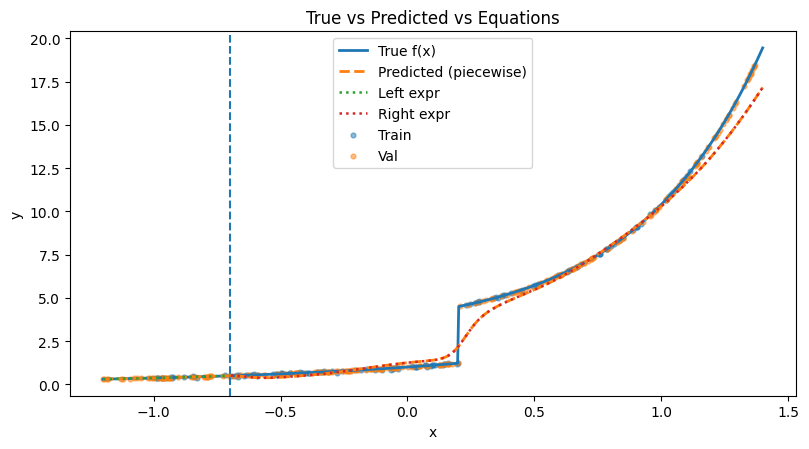

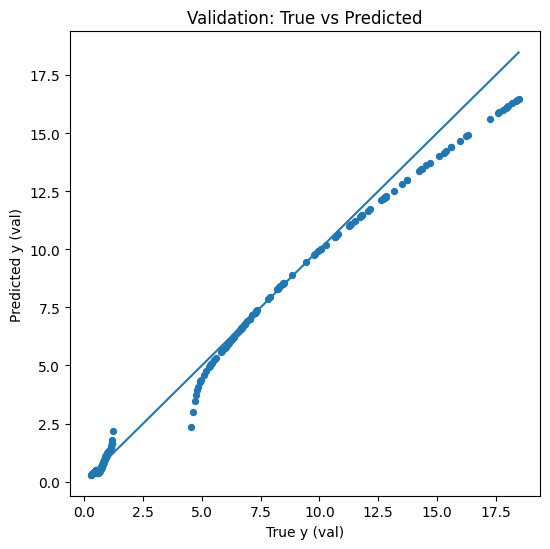

Left  f_L(x): exp(x0)
Right f_R(x): ((2 - (sin(sin(((2.74393 - (sin(((-0.136519 + sin((x0 * (x0 - 3.14159)))) - (sin(((x0 * (x0 - 2.71828)) * 0.5)) / x0)...
Boundary t* = -0.6993126887739635


In [18]:
# --- Plot: true vs predicted (piecewise) + show learned equations ---
# Requirements in scope:
# - best: dict from piecewise_search(...) with keys ["t","left_tree","right_tree"]
# - ground_truth(x): callable returning true y for vector x
# - predict_piecewise(left_tree, right_tree, t, X): from earlier cell
# - serialize(), eval_tree()
# - (optional) X_train, y_train, X_val, y_val for context

import numpy as np
import matplotlib.pyplot as plt

def plot_piecewise_result(best, ground_truth, X_train=None, y_train=None, X_val=None, y_val=None,
                          x_min=-1.2, x_max=1.4, n_points=600, title="True vs Predicted vs Equations"):
    t = float(best["t"])
    fL, fR = best["left_tree"], best["right_tree"]
    expr_L = serialize(fL)
    expr_R = serialize(fR)

    # Dense grid
    xs = np.linspace(x_min, x_max, n_points).reshape(-1, 1)
    y_true = ground_truth(xs.ravel())

    # Predicted (piecewise)
    y_pred = predict_piecewise(fL, fR, t, xs)

    # Also evaluate left/right expressions on their respective sides for display
    Lmask = xs.ravel() <= t
    Rmask = ~Lmask
    y_left_curve  = np.empty_like(xs.ravel(), dtype=float);  y_left_curve[:]  = np.nan
    y_right_curve = np.empty_like(xs.ravel(), dtype=float);  y_right_curve[:] = np.nan
    if Lmask.any():
        y_left_curve[Lmask]  = eval_tree(fL, xs[Lmask])
    if Rmask.any():
        y_right_curve[Rmask] = eval_tree(fR, xs[Rmask])

    # --- Figure 1: function view ---
    plt.figure(figsize=(8.2, 4.6))
    plt.plot(xs.ravel(), y_true, label="True f(x)", linewidth=2.0)
    plt.plot(xs.ravel(), y_pred, "--", label="Predicted (piecewise)", linewidth=2.0)
    plt.plot(xs.ravel(), y_left_curve,  ":", label="Left expr",  linewidth=1.8)
    plt.plot(xs.ravel(), y_right_curve, ":", label="Right expr", linewidth=1.8)

    if X_train is not None and y_train is not None:
        plt.scatter(X_train[:,0], y_train, s=12, alpha=0.5, label="Train")
    if X_val is not None and y_val is not None:
        plt.scatter(X_val[:,0], y_val, s=12, alpha=0.5, label="Val")

    plt.axvline(t, linestyle="--")
    plt.xlabel("x"); plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Figure 2: Validation scatter (y_true vs y_pred) if val provided ---
    if X_val is not None and y_val is not None:
        yhat_val = predict_piecewise(fL, fR, t, X_val)
        plt.figure(figsize=(5.6, 5.6))
        plt.scatter(y_val, yhat_val, s=18)
        mn, mx = float(min(np.min(y_val), np.min(yhat_val))), float(max(np.max(y_val), np.max(yhat_val)))
        plt.plot([mn, mx], [mn, mx])
        plt.xlabel("True y (val)"); plt.ylabel("Predicted y (val)")
        plt.title("Validation: True vs Predicted")
        plt.tight_layout()
        plt.show()

    # Print equations (truncated if very long)
    def _truncate(s, n=120):
        return s if len(s) <= n else s[:n-3] + "..."
    print("Left  f_L(x):", _truncate(expr_L))
    print("Right f_R(x):", _truncate(expr_R))
    print("Boundary t* =", t)

# Example use (after running piecewise_search and having ground_truth):
plot_piecewise_result(best, ground_truth, X_train, y_train, X_val, y_val)


# Better initial candidates:

In [38]:
# genetic_symbolic_regression.py
# Minimal genetic programming for symbolic regression
# Ops: +, -, *, /, exp, log, sin, cos
# Demo target: y = exp(2x) (with noisy train samples)

import math
import random
from typing import Tuple, List
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# 1) Expression representation
#    Node types (nested tuples):
#       ("const", value)
#       ("var", idx)                  # x[idx], here we will use idx=0 (single variable)
#       ("op", "opname", left, right) # binary ops
#       ("uop", "opname", child)      # unary ops
# ------------------------------

BINARY_OPS = ("+", "-", "*", "/")
UNARY_OPS  = ("exp", "log", "sin", "cos")
# UNARY_OPS  = ("exp")

def safe_div(a, b):
    return a / (b + 1e-8)

def safe_log(a):
    return np.log(np.abs(a) + 1e-8)

OP_TABLE = {
    "+": lambda a,b: a + b,
    "-": lambda a,b: a - b,
    "*": lambda a,b: a * b,
    "/": safe_div,
}
UOP_TABLE = {
    "exp": np.exp,
    "log": safe_log,
    "sin": np.sin,
    "cos": np.cos,
}

def random_const():
    # bias toward useful small constants to speed up convergence
    choices = [0.5, 1.0, 2.0, 3.0, math.e, math.pi]
    if random.random() < 0.6:
        return ("const", random.choice(choices))
    return ("const", random.uniform(-3.0, 3.0))

def random_var(n_vars=1):
    # choose which x[idx] to use (supports multivariate if you set n_vars>1)
    return ("var", random.randrange(n_vars))

def random_leaf(n_vars=1):
    return random_var(n_vars) if random.random() < 0.5 else random_const()

def random_tree(max_depth: int, n_vars=1):
    if max_depth == 0 or random.random() < 0.35:
        return random_leaf(n_vars)
    if random.random() < 0.5:
        op = random.choice(BINARY_OPS)
        return ("op", op,
                random_tree(max_depth-1, n_vars),
                random_tree(max_depth-1, n_vars))
    else:
        op = random.choice(UNARY_OPS)
        return ("uop", op, random_tree(max_depth-1, n_vars))

def tree_size(t) -> int:
    tag = t[0]
    if tag in ("const", "var"):
        return 1
    if tag == "op":
        return 1 + tree_size(t[2]) + tree_size(t[3])
    if tag == "uop":
        return 1 + tree_size(t[2])
    raise ValueError("Bad node")

def eval_tree(t, X: np.ndarray) -> np.ndarray:
    """Evaluate tree on X of shape (N, D)."""
    tag = t[0]
    if tag == "const":
        return np.full(X.shape[0], float(t[1]), dtype=float)
    if tag == "var":
        idx = int(t[1])
        return X[:, idx]
    if tag == "op":
        f = OP_TABLE[t[1]]
        return f(eval_tree(t[2], X), eval_tree(t[3], X))
    if tag == "uop":
        f = UOP_TABLE[t[1]]
        return f(eval_tree(t[2], X))
    raise ValueError("Bad node")

def serialize(t) -> str:
    tag = t[0]
    if tag == "const":
        v = float(t[1])
        if abs(v - round(v)) < 1e-12:
            return str(int(round(v)))
        return f"{v:.6g}"
    if tag == "var":
        return f"x{t[1]}"
    if tag == "op":
        return f"({serialize(t[2])} {t[1]} {serialize(t[3])})"
    if tag == "uop":
        return f"{t[1]}({serialize(t[2])})"
    raise ValueError("Bad node")

# ------------------------------
# 2) Genetic operators
# ------------------------------

def mutate(t, max_depth=3, n_vars=1, p_change_const=0.5):
    # replace whole subtree sometimes
    if random.random() < 0.2:
        return random_tree(max_depth, n_vars)
    tag = t[0]
    if tag == "const":
        if random.random() < p_change_const:
            return random_const()
        return ("const", float(t[1]) + random.uniform(-0.5, 0.5))
    if tag == "var":
        # occasionally switch which variable
        if random.random() < 0.1 and n_vars > 1:
            return ("var", random.randrange(n_vars))
        return t
    if tag == "op":
        # possibly swap operator
        if random.random() < 0.2:
            return ("op", random.choice(BINARY_OPS), t[2], t[3])
        return ("op", t[1], mutate(t[2], max_depth, n_vars), mutate(t[3], max_depth, n_vars))
    if tag == "uop":
        if random.random() < 0.2:
            return ("uop", random.choice(UNARY_OPS), t[2])
        return ("uop", t[1], mutate(t[2], max_depth, n_vars))
    return t

def _enumerate_nodes(t, path=None, out=None):
    if path is None:
        path = []
    if out is None:
        out = []
    out.append((path, t))
    tag = t[0]
    if tag == "op":
        _enumerate_nodes(t[2], path + [2], out)
        _enumerate_nodes(t[3], path + [3], out)
    elif tag == "uop":
        _enumerate_nodes(t[2], path + [2], out)
    return out

def random_subtree(t):
    nodes = _enumerate_nodes(t)
    return random.choice(nodes)  # (path, node)

def set_subtree(t, path: List[int], new_sub):
    if not path:
        return new_sub
    head, rest = path[0], path[1:]
    tag = t[0]
    if tag == "op":
        if head == 2:
            return ("op", t[1], set_subtree(t[2], rest, new_sub), t[3])
        else:
            return ("op", t[1], t[2], set_subtree(t[3], rest, new_sub))
    if tag == "uop":
        return ("uop", t[1], set_subtree(t[2], rest, new_sub))
    return t

def crossover(a, b):
    path_a, _ = random_subtree(a)
    _, sub_b  = random_subtree(b)
    return set_subtree(a, path_a, sub_b)

# ------------------------------
# 3) Fitness & evolution
# ------------------------------

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred)**2)))

def fitness(t, X, y, alpha_size=1e-3):
    try:
        yp = eval_tree(t, X)
        if not np.all(np.isfinite(yp)) or np.any(np.abs(yp) > 1e6):
            return 1e9
        err = rmse(y, yp)
        comp = alpha_size * tree_size(t)   # complexity penalty keeps formulas small
        return err + comp
    except Exception:
        return 1e9

def evolve(
    X, y, n_vars=1, pop_size=200, generations=60,
    max_depth=4, elite_frac=0.05,
    p_mutate=0.6, p_crossover=0.35, tournament_k=4,
    rng_seed=0
):
    random.seed(rng_seed)
    pop = [random_tree(max_depth, n_vars) for _ in range(pop_size)]
    scores = [fitness(t, X, y) for t in pop]

    def tournament():
        cand = random.sample(range(pop_size), tournament_k)
        best_i = min(cand, key=lambda i: scores[i])
        return pop[best_i]

    history = []
    for _ in range(generations):
        scores = [fitness(t, X, y) for t in pop]
        order = np.argsort(scores)
        pop = [pop[i] for i in order]
        scores = [scores[i] for i in order]
        history.append(scores[0])

        next_pop = []
        elite_n = max(1, int(elite_frac * pop_size))
        next_pop.extend(pop[:elite_n])  # elitism

        while len(next_pop) < pop_size:
            r = random.random()
            if r < p_crossover:
                a, b = tournament(), tournament()
                child = crossover(a, b)
            elif r < p_crossover + p_mutate:
                a = tournament()
                child = mutate(a, max_depth=max_depth, n_vars=n_vars)
            else:
                child = random_tree(max_depth, n_vars)
            next_pop.append(child)
        pop = next_pop

    scores = [fitness(t, X, y) for t in pop]
    best_idx = int(np.argmin(scores))
    return pop[best_idx], float(scores[best_idx]), history




In [39]:
# ============================================================
# Piecewise symbolic regression with ONE decision boundary (genetic per side)
# - Reuses your GP: evolve(), eval_tree(), serialize(), rmse(), (optionally tree_size)
# - Searches for the best split t (decision boundary) and two expressions (left/right)
# - Objective = piecewise RMSE + lambda_cont * continuity_gap^2 (+ optional size penalty)
# ============================================================

import numpy as np

# ---------- Config ----------
LAMBDA_CONT = 1.0     # continuity penalty weight (start with 1.0)
BETA_SIZE   = 0.0     # set 0.0 now (no cost for decision boundary). Later: >0
USE_SLOPE_CONT = False
FD_EPS = 1e-4         # finite-difference step if slope continuity enabled

# GP hyperparams per-side (you can tweak)
GP_KW = dict(pop_size=200, generations=80, max_depth=5)
SEEDS_PER_SIDE = [2, 7, 11]  # try multiple seeds and keep best per side

# ---------- Utilities ----------
def _has_tree_size():
    try:
        _ = tree_size  # noqa: F821
        return True
    except NameError:
        return False

def _size_or_zero(tree):
    if _has_tree_size():
        return tree_size(tree)  # noqa: F821
    return 0

def _finite_diff_slope(tree, t):
    """Approximate f'(t) with central finite differences on scalar x."""
    Xp = np.array([[t + FD_EPS]], dtype=float)
    Xm = np.array([[t - FD_EPS]], dtype=float)
    yp = float(eval_tree(tree, Xp))  # noqa: F821
    ym = float(eval_tree(tree, Xm))  # noqa: F821
    return (yp - ym) / (2.0 * FD_EPS)

def _fit_side(X, y, mask, seeds, gp_kw):
    """Fit one side by trying multiple seeds; return (best_tree, best_rmse, best_seed)."""
    X_side, y_side = X[mask], y[mask]
    if X_side.shape[0] == 0:
        return None, np.inf, None

    best = None
    best_score = np.inf
    best_seed = None

    # Try multiple seeds; keep best by (RMSE + small size penalty to break ties)
    for sd in seeds:
        # evolve may accept rng_seed or seed depending on your earlier definition
        try:
            tree, score, _ = evolve(X_side, y_side, seed=sd, **gp_kw)  # noqa: F821
        except TypeError:
            tree, score, _ = evolve(X_side, y_side, rng_seed=sd, **gp_kw)  # noqa: F821

        y_hat = eval_tree(tree, X_side)  # noqa: F821
        side_rmse = rmse(y_side, y_hat)  # noqa: F821
        tie_break = 1e-6 * _size_or_zero(tree)
        this_score = side_rmse + tie_break
        if this_score < best_score:
            best_score = this_score
            best = tree
            best_seed = sd

    # Recompute pure RMSE for reporting
    y_hat = eval_tree(best, X_side)     # noqa: F821
    pure_rmse = rmse(y_side, y_hat)     # noqa: F821
    return best, pure_rmse, best_seed

def _objective_piecewise(left_tree, right_tree, t, X, y):
    """Compute total objective and components for a given pair and threshold."""
    x = X[:, 0]
    L = x <= t
    R = ~L
    if L.sum() == 0 or R.sum() == 0:
        return dict(obj=np.inf, rmse=np.inf, left_rmse=np.inf, right_rmse=np.inf,
                    gap=np.inf, slope_gap=np.inf, size_pen=0.0)

    # Per-side predictions and RMSE
    yL_hat = eval_tree(left_tree,  X[L])   # noqa: F821
    yR_hat = eval_tree(right_tree, X[R])   # noqa: F821
    left_rmse  = rmse(y[L], yL_hat)        # noqa: F821
    right_rmse = rmse(y[R], yR_hat)        # noqa: F821

    # Combine into overall RMSE
    N = float(len(y))
    piecewise_rmse = np.sqrt(((y[L] - yL_hat)**2).sum() + ((y[R] - yR_hat)**2).sum()) / np.sqrt(N)

    # Continuity penalty at boundary
    tX = np.array([[t]], dtype=float)
    fL_t = float(eval_tree(left_tree, tX))     # noqa: F821
    fR_t = float(eval_tree(right_tree, tX))    # noqa: F821
    gap = fL_t - fR_t
    cont_pen = LAMBDA_CONT * (gap * gap)

    # Optional slope continuity
    slope_pen = 0.0
    slope_gap_val = np.nan
    if USE_SLOPE_CONT:
        dL = _finite_diff_slope(left_tree, t)
        dR = _finite_diff_slope(right_tree, t)
        slope_gap_val = dL - dR
        slope_pen = LAMBDA_CONT * (slope_gap_val * slope_gap_val)

    # Optional size penalty (currently 0.0 by default)
    size_pen = BETA_SIZE * (_size_or_zero(left_tree) + _size_or_zero(right_tree))

    total = piecewise_rmse + cont_pen + slope_pen + size_pen
    return dict(
        obj=total, rmse=piecewise_rmse,
        left_rmse=left_rmse, right_rmse=right_rmse,
        gap=gap, slope_gap=slope_gap_val,
        size_pen=size_pen
    )

def build_threshold_candidates(X, q_lo=0.1, q_hi=0.9, num=17):
    """Quantile-based candidate thresholds between q_lo and q_hi."""
    xs = np.sort(X[:, 0])
    qs = np.linspace(q_lo, q_hi, num=num)
    t_list = np.quantile(xs, qs)
    # ensure uniqueness and numeric
    t_list = np.unique(np.asarray(t_list, dtype=float))
    return t_list

def piecewise_search(
    X, y, t_candidates=None,
    seeds_per_side=SEEDS_PER_SIDE, gp_kw=GP_KW
):
    """Search over thresholds; for each threshold, fit left/right GPs and score.
       Returns best triple (left_tree, right_tree, t) and a log of all trials.
    """
    if t_candidates is None:
        t_candidates = build_threshold_candidates(X)

    trials = []
    best_pack = None
    best_obj = np.inf

    for t in t_candidates:
        x = X[:, 0]
        Lmask = x <= t
        Rmask = ~Lmask
        # guard
        if Lmask.sum() < 5 or Rmask.sum() < 5:
            continue

        left_tree,  left_rmse,  left_seed  = _fit_side(X, y, Lmask, seeds_per_side, gp_kw)
        right_tree, right_rmse, right_seed = _fit_side(X, y, Rmask, seeds_per_side, gp_kw)

        if left_tree is None or right_tree is None:
            continue

        comp = _objective_piecewise(left_tree, right_tree, t, X, y)
        trials.append(dict(
            t=float(t),
            left_expr=serialize(left_tree),    # noqa: F821
            right_expr=serialize(right_tree),  # noqa: F821
            left_rmse=float(comp["left_rmse"]),
            right_rmse=float(comp["right_rmse"]),
            rmse=float(comp["rmse"]),
            gap=float(comp["gap"]),
            size_pen=float(comp["size_pen"]),
            obj=float(comp["obj"]),
            left_seed=left_seed,
            right_seed=right_seed,
            left_size=_size_or_zero(left_tree),
            right_size=_size_or_zero(right_tree)
        ))

        if comp["obj"] < best_obj:
            best_obj = comp["obj"]
            best_pack = dict(
                t=float(t),
                left_tree=left_tree,
                right_tree=right_tree,
                metrics=comp
            )

    return best_pack, trials

# ---------- Demo hook (optional) ----------
# If you already have (X_train, y_train) in memory from your ground-truth step,
# run:
# best, log = piecewise_search(X_train, y_train)
# print("Best t:", best["t"])
# print("Left:", serialize(best["left_tree"]))
# print("Right:", serialize(best["right_tree"]))
# print("Metrics:", best["metrics"])


/tmp/ipython-input-3677451679.py:93: RuntimeWarning: overflow encountered in exp
  return f(eval_tree(t[2], X))
/tmp/ipython-input-3677451679.py:93: RuntimeWarning: invalid value encountered in cos
  return f(eval_tree(t[2], X))
/tmp/ipython-input-3677451679.py:93: RuntimeWarning: invalid value encountered in sin
  return f(eval_tree(t[2], X))
/tmp/ipython-input-4089730518.py:94: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fL_t = float(eval_tree(left_tree, tX))     # noqa: F821
/tmp/ipython-input-4089730518.py:95: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fR_t = float(eval_tree(right_tree, tX))    # noqa: F821
/tmp/ipython-input-367

=== Best Split ===
t* = -0.6993126887739635
Left  f_L(x): exp(x0)
Right f_R(x): ((2 - (sin(sin(((2.74393 - (sin(((-0.136519 + sin((x0 * (x0 - 3.14159)))) - (sin(((x0 * (x0 - 2.71828)) * 0.5)) / x0))) - x0)) * (((x0 + exp(x0)) / (2 - (sin(sin(((2.74393 - (sin(((-0.136519 + sin((x0 * (x0 - 3.14159)))) - (sin(((x0 * (x0 - 2.71828)) * 0.5)) / x0))) - x0)) * (((sin(((-0.136519 + sin((x0 * (x0 - 3.14159)))) - (sin(((x0 * (x0 - 2.71828)) * 0.5)) / x0))) + exp(x0)) / 2.71828) - 3.14159)))) - x0))) - 3.14159)))) - x0)) * exp(x0))
Metrics: {'obj': np.float64(0.36438339572722406), 'rmse': np.float64(0.3640538913698413), 'left_rmse': 0.02927368180303861, 'right_rmse': 0.3836224141535436, 'gap': -0.018152254884249763, 'slope_gap': nan, 'size_pen': 0.0}
Val RMSE: 0.5679336546208782


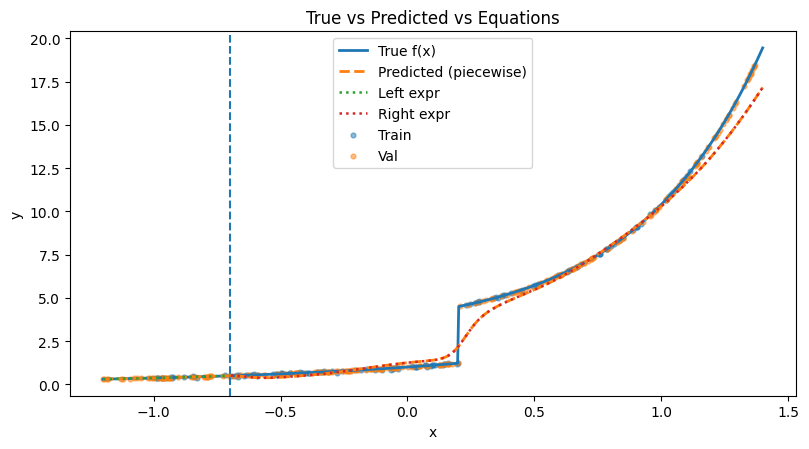

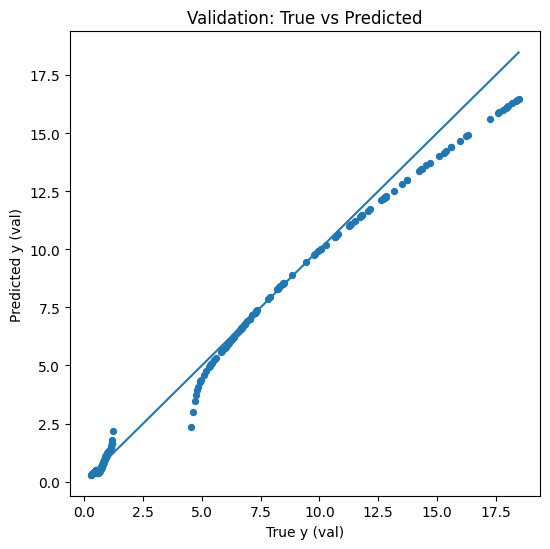

Left  f_L(x): exp(x0)
Right f_R(x): ((2 - (sin(sin(((2.74393 - (sin(((-0.136519 + sin((x0 * (x0 - 3.14159)))) - (sin(((x0 * (x0 - 2.71828)) * 0.5)) / x0)...
Boundary t* = -0.6993126887739635


In [40]:
# Assuming you already created (X_train, y_train) for your piecewise ground truth:
best, trials = piecewise_search(X_train, y_train)

print("=== Best Split ===")
print("t* =", best["t"])
print("Left  f_L(x):", serialize(best["left_tree"]))
print("Right f_R(x):", serialize(best["right_tree"]))
print("Metrics:", best["metrics"])

# Optional: evaluate on validation set (X_val, y_val)
def predict_piecewise(left_tree, right_tree, t, X):
    x = X[:, 0]
    out = np.empty_like(x, dtype=float)
    L = x <= t
    R = ~L
    out[L] = eval_tree(left_tree,  X[L])
    out[R] = eval_tree(right_tree, X[R])
    return out

yhat_val = predict_piecewise(best["left_tree"], best["right_tree"], best["t"], X_val)
print("Val RMSE:", rmse(y_val, yhat_val))

# --- Plot: true vs predicted (piecewise) + show learned equations ---
# Requirements in scope:
# - best: dict from piecewise_search(...) with keys ["t","left_tree","right_tree"]
# - ground_truth(x): callable returning true y for vector x
# - predict_piecewise(left_tree, right_tree, t, X): from earlier cell
# - serialize(), eval_tree()
# - (optional) X_train, y_train, X_val, y_val for context

import numpy as np
import matplotlib.pyplot as plt

def plot_piecewise_result(best, ground_truth, X_train=None, y_train=None, X_val=None, y_val=None,
                          x_min=-1.2, x_max=1.4, n_points=600, title="True vs Predicted vs Equations"):
    t = float(best["t"])
    fL, fR = best["left_tree"], best["right_tree"]
    expr_L = serialize(fL)
    expr_R = serialize(fR)

    # Dense grid
    xs = np.linspace(x_min, x_max, n_points).reshape(-1, 1)
    y_true = ground_truth(xs.ravel())

    # Predicted (piecewise)
    y_pred = predict_piecewise(fL, fR, t, xs)

    # Also evaluate left/right expressions on their respective sides for display
    Lmask = xs.ravel() <= t
    Rmask = ~Lmask
    y_left_curve  = np.empty_like(xs.ravel(), dtype=float);  y_left_curve[:]  = np.nan
    y_right_curve = np.empty_like(xs.ravel(), dtype=float);  y_right_curve[:] = np.nan
    if Lmask.any():
        y_left_curve[Lmask]  = eval_tree(fL, xs[Lmask])
    if Rmask.any():
        y_right_curve[Rmask] = eval_tree(fR, xs[Rmask])

    # --- Figure 1: function view ---
    plt.figure(figsize=(8.2, 4.6))
    plt.plot(xs.ravel(), y_true, label="True f(x)", linewidth=2.0)
    plt.plot(xs.ravel(), y_pred, "--", label="Predicted (piecewise)", linewidth=2.0)
    plt.plot(xs.ravel(), y_left_curve,  ":", label="Left expr",  linewidth=1.8)
    plt.plot(xs.ravel(), y_right_curve, ":", label="Right expr", linewidth=1.8)

    if X_train is not None and y_train is not None:
        plt.scatter(X_train[:,0], y_train, s=12, alpha=0.5, label="Train")
    if X_val is not None and y_val is not None:
        plt.scatter(X_val[:,0], y_val, s=12, alpha=0.5, label="Val")

    plt.axvline(t, linestyle="--")
    plt.xlabel("x"); plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Figure 2: Validation scatter (y_true vs y_pred) if val provided ---
    if X_val is not None and y_val is not None:
        yhat_val = predict_piecewise(fL, fR, t, X_val)
        plt.figure(figsize=(5.6, 5.6))
        plt.scatter(y_val, yhat_val, s=18)
        mn, mx = float(min(np.min(y_val), np.min(yhat_val))), float(max(np.max(y_val), np.max(yhat_val)))
        plt.plot([mn, mx], [mn, mx])
        plt.xlabel("True y (val)"); plt.ylabel("Predicted y (val)")
        plt.title("Validation: True vs Predicted")
        plt.tight_layout()
        plt.show()

    # Print equations (truncated if very long)
    def _truncate(s, n=120):
        return s if len(s) <= n else s[:n-3] + "..."
    print("Left  f_L(x):", _truncate(expr_L))
    print("Right f_R(x):", _truncate(expr_R))
    print("Boundary t* =", t)

# Example use (after running piecewise_search and having ground_truth):
plot_piecewise_result(best, ground_truth, X_train, y_train, X_val, y_val)



# Lamda =0

/tmp/ipython-input-2481395598.py:92: RuntimeWarning: overflow encountered in exp
  return f(eval_tree(t[2], X))
/tmp/ipython-input-2481395598.py:92: RuntimeWarning: invalid value encountered in cos
  return f(eval_tree(t[2], X))
/tmp/ipython-input-2481395598.py:92: RuntimeWarning: invalid value encountered in sin
  return f(eval_tree(t[2], X))
/tmp/ipython-input-4089730518.py:94: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fL_t = float(eval_tree(left_tree, tX))     # noqa: F821
/tmp/ipython-input-4089730518.py:95: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fR_t = float(eval_tree(right_tree, tX))    # noqa: F821
/tmp/ipython-input-248

=== Best Split ===
t* = 0.211164044130585
Left  f_L(x): exp(x0)
Right f_R(x): (exp((x0 + x0)) + 3)
Metrics: {'obj': np.float64(0.02993585130480054), 'rmse': np.float64(0.02993585130480054), 'left_rmse': 0.03309423647893691, 'right_rmse': 0.024444738721698854, 'gap': -3.290393992362824, 'slope_gap': nan, 'size_pen': 0.0}
Val RMSE: 0.21208658747774722


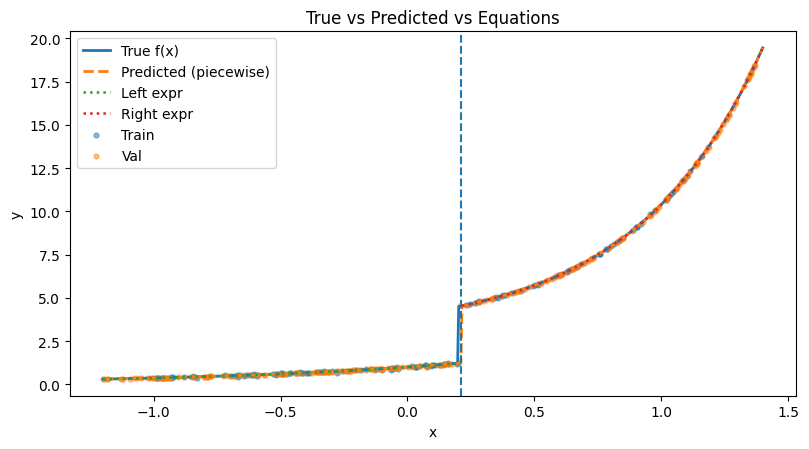

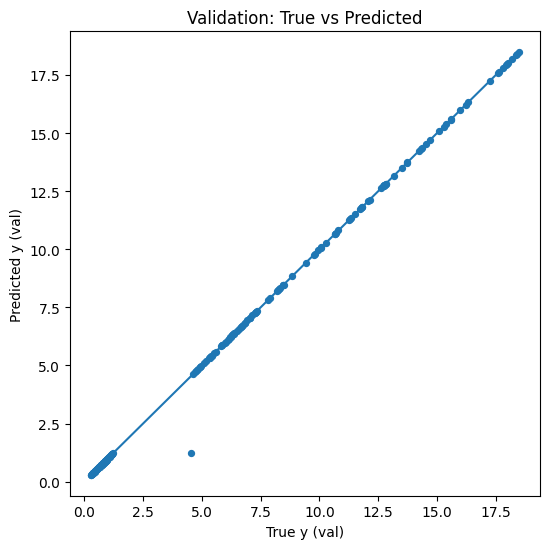

Left  f_L(x): exp(x0)
Right f_R(x): (exp((x0 + x0)) + 3)
Boundary t* = 0.211164044130585


In [22]:
# ---------- Config ----------
LAMBDA_CONT = 0.0     # continuity penalty weight (start with 1.0)
BETA_SIZE   = 0.0     # set 0.0 now (no cost for decision boundary). Later: >0
USE_SLOPE_CONT = False
FD_EPS = 1e-4         # finite-difference step if slope continuity enabled

# Assuming you already created (X_train, y_train) for your piecewise ground truth:
best, trials = piecewise_search(X_train, y_train)

print("=== Best Split ===")
print("t* =", best["t"])
print("Left  f_L(x):", serialize(best["left_tree"]))
print("Right f_R(x):", serialize(best["right_tree"]))
print("Metrics:", best["metrics"])

# Optional: evaluate on validation set (X_val, y_val)
def predict_piecewise(left_tree, right_tree, t, X):
    x = X[:, 0]
    out = np.empty_like(x, dtype=float)
    L = x <= t
    R = ~L
    out[L] = eval_tree(left_tree,  X[L])
    out[R] = eval_tree(right_tree, X[R])
    return out

yhat_val = predict_piecewise(best["left_tree"], best["right_tree"], best["t"], X_val)
print("Val RMSE:", rmse(y_val, yhat_val))

# --- Plot: true vs predicted (piecewise) + show learned equations ---
# Requirements in scope:
# - best: dict from piecewise_search(...) with keys ["t","left_tree","right_tree"]
# - ground_truth(x): callable returning true y for vector x
# - predict_piecewise(left_tree, right_tree, t, X): from earlier cell
# - serialize(), eval_tree()
# - (optional) X_train, y_train, X_val, y_val for context

import numpy as np
import matplotlib.pyplot as plt

def plot_piecewise_result(best, ground_truth, X_train=None, y_train=None, X_val=None, y_val=None,
                          x_min=-1.2, x_max=1.4, n_points=600, title="True vs Predicted vs Equations"):
    t = float(best["t"])
    fL, fR = best["left_tree"], best["right_tree"]
    expr_L = serialize(fL)
    expr_R = serialize(fR)

    # Dense grid
    xs = np.linspace(x_min, x_max, n_points).reshape(-1, 1)
    y_true = ground_truth(xs.ravel())

    # Predicted (piecewise)
    y_pred = predict_piecewise(fL, fR, t, xs)

    # Also evaluate left/right expressions on their respective sides for display
    Lmask = xs.ravel() <= t
    Rmask = ~Lmask
    y_left_curve  = np.empty_like(xs.ravel(), dtype=float);  y_left_curve[:]  = np.nan
    y_right_curve = np.empty_like(xs.ravel(), dtype=float);  y_right_curve[:] = np.nan
    if Lmask.any():
        y_left_curve[Lmask]  = eval_tree(fL, xs[Lmask])
    if Rmask.any():
        y_right_curve[Rmask] = eval_tree(fR, xs[Rmask])

    # --- Figure 1: function view ---
    plt.figure(figsize=(8.2, 4.6))
    plt.plot(xs.ravel(), y_true, label="True f(x)", linewidth=2.0)
    plt.plot(xs.ravel(), y_pred, "--", label="Predicted (piecewise)", linewidth=2.0)
    plt.plot(xs.ravel(), y_left_curve,  ":", label="Left expr",  linewidth=1.8)
    plt.plot(xs.ravel(), y_right_curve, ":", label="Right expr", linewidth=1.8)

    if X_train is not None and y_train is not None:
        plt.scatter(X_train[:,0], y_train, s=12, alpha=0.5, label="Train")
    if X_val is not None and y_val is not None:
        plt.scatter(X_val[:,0], y_val, s=12, alpha=0.5, label="Val")

    plt.axvline(t, linestyle="--")
    plt.xlabel("x"); plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Figure 2: Validation scatter (y_true vs y_pred) if val provided ---
    if X_val is not None and y_val is not None:
        yhat_val = predict_piecewise(fL, fR, t, X_val)
        plt.figure(figsize=(5.6, 5.6))
        plt.scatter(y_val, yhat_val, s=18)
        mn, mx = float(min(np.min(y_val), np.min(yhat_val))), float(max(np.max(y_val), np.max(yhat_val)))
        plt.plot([mn, mx], [mn, mx])
        plt.xlabel("True y (val)"); plt.ylabel("Predicted y (val)")
        plt.title("Validation: True vs Predicted")
        plt.tight_layout()
        plt.show()

    # Print equations (truncated if very long)
    def _truncate(s, n=120):
        return s if len(s) <= n else s[:n-3] + "..."
    print("Left  f_L(x):", _truncate(expr_L))
    print("Right f_R(x):", _truncate(expr_R))
    print("Boundary t* =", t)

# Example use (after running piecewise_search and having ground_truth):
plot_piecewise_result(best, ground_truth, X_train, y_train, X_val, y_val)



# What if there are two decision boundaries (Parallel)

In [23]:
# ============================================================
# Piecewise symbolic regression with TWO decision boundaries
#   Domains: x <= t1  |  t1 < x <= t2  |  x > t2
#   Models:  f1(x)    |     f2(x)      |  f3(x)
#
# Uses your SAME GP functions: evolve(), eval_tree(), serialize(), rmse()
# Optional: tree_size()
# Boundaries can be scanned via quantiles, and/or proposed by a CART tree.
# Objective = piecewise RMSE
#            + lambda_cont * ( (f1(t1)-f2(t1))^2 + (f2(t2)-f3(t2))^2 )
#            + (optional) slope-continuity + (optional) size penalty
#            + (currently 0) boundary penalty (add later)
# ============================================================

import numpy as np
from itertools import combinations
from typing import Optional, List, Tuple, Dict

# ---------------- Config ----------------
LAMBDA_CONT = 1.0     # continuity weight; tune this
USE_SLOPE_CONT = False
FD_EPS = 1e-4

BETA_SIZE = 0.0       # keep 0.0 now (no structural penalty); set >0 later
SEEDS_PER_SIDE = [2, 7]   # a couple seeds per segment to keep runtime reasonable
GP_KW = dict(pop_size=180, generations=70, max_depth=5)

# ------------- Optional helpers -------------
def _has_tree_size():
    try:
        _ = tree_size  # noqa: F821
        return True
    except NameError:
        return False

def _size_or_zero(tree):
    if _has_tree_size():
        return tree_size(tree)  # noqa: F821
    return 0

def _finite_diff_slope(tree, t):
    Xp = np.array([[t + FD_EPS]], dtype=float)
    Xm = np.array([[t - FD_EPS]], dtype=float)
    yp = float(eval_tree(tree, Xp))  # noqa: F821
    ym = float(eval_tree(tree, Xm))  # noqa: F821
    return (yp - ym) / (2.0 * FD_EPS)

# ------------- Fit one segment -------------
def _fit_segment(X, y, mask, seeds, gp_kw):
    Xs, ys = X[mask], y[mask]
    if Xs.shape[0] == 0:
        return None, np.inf, None
    best, best_score, best_seed = None, np.inf, None
    for sd in seeds:
        try:
            tree, score, _ = evolve(Xs, ys, seed=sd, **gp_kw)      # noqa: F821
        except TypeError:
            tree, score, _ = evolve(Xs, ys, rng_seed=sd, **gp_kw)  # noqa: F821
        yhat = eval_tree(tree, Xs)                                 # noqa: F821
        seg_rmse = rmse(ys, yhat)                                  # noqa: F821
        tie = 1e-6 * _size_or_zero(tree)
        s = seg_rmse + tie
        if s < best_score:
            best, best_score, best_seed = tree, s, sd
    # recompute pure RMSE for reporting
    yhat = eval_tree(best, Xs)                                     # noqa: F821
    pure = rmse(ys, yhat)                                          # noqa: F821
    return best, pure, best_seed

# ------------- Objective for 3 segments -------------
def _objective_piecewise3(f1, f2, f3, t1, t2, X, y):
    x = X[:, 0]
    L1 = x <= t1
    L2 = (x > t1) & (x <= t2)
    L3 = x > t2
    if (L1.sum() < 3) or (L2.sum() < 3) or (L3.sum() < 3):
        return dict(obj=np.inf, rmse=np.inf, rmse1=np.inf, rmse2=np.inf, rmse3=np.inf,
                    gap1=np.inf, gap2=np.inf, slope_gap1=np.nan, slope_gap2=np.nan,
                    size_pen=0.0)

    # per-segment RMSEs
    y1 = eval_tree(f1, X[L1]);  r1 = rmse(y[L1], y1)   # noqa: F821
    y2 = eval_tree(f2, X[L2]);  r2 = rmse(y[L2], y2)   # noqa: F821
    y3 = eval_tree(f3, X[L3]);  r3 = rmse(y[L3], y3)   # noqa: F821

    N = float(len(y))
    piece_rmse = np.sqrt(((y[L1]-y1)**2).sum() + ((y[L2]-y2)**2).sum() + ((y[L3]-y3)**2).sum()) / np.sqrt(N)

    # value continuity penalties at t1, t2
    t1X = np.array([[t1]], dtype=float)
    t2X = np.array([[t2]], dtype=float)
    g1 = float(eval_tree(f1, t1X) - eval_tree(f2, t1X))           # noqa: F821
    g2 = float(eval_tree(f2, t2X) - eval_tree(f3, t2X))           # noqa: F821
    cont_pen = LAMBDA_CONT * (g1*g1 + g2*g2)

    slope_pen = 0.0; sg1 = np.nan; sg2 = np.nan
    if USE_SLOPE_CONT:
        d1 = _finite_diff_slope(f1, t1); d2 = _finite_diff_slope(f2, t1)
        d3 = _finite_diff_slope(f2, t2); d4 = _finite_diff_slope(f3, t2)
        sg1 = d1 - d2; sg2 = d3 - d4
        slope_pen = LAMBDA_CONT * (sg1*sg1 + sg2*sg2)

    size_pen = BETA_SIZE * (_size_or_zero(f1) + _size_or_zero(f2) + _size_or_zero(f3))

    total = piece_rmse + cont_pen + slope_pen + size_pen
    return dict(
        obj=total, rmse=piece_rmse, rmse1=r1, rmse2=r2, rmse3=r3,
        gap1=g1, gap2=g2, slope_gap1=sg1, slope_gap2=sg2, size_pen=size_pen
    )

# ------------- Threshold candidates (quantile grid) -------------
def build_two_threshold_candidates(X, q_lo=0.15, q_hi=0.85, num_q=9):
    """Return array of (t1,t2) with t1<t2 from quantiles."""
    xs = np.sort(X[:, 0])
    qs = np.linspace(q_lo, q_hi, num=num_q)
    qs = np.unique(qs)
    ts = np.unique(np.quantile(xs, qs))
    pairs = []
    for i, j in combinations(range(len(ts)), 2):
        t1, t2 = float(ts[i]), float(ts[j])
        if t2 - t1 > 1e-6:
            pairs.append((t1, t2))
    return np.array(pairs, dtype=float)

# ------------- CART proposals (depth-2) -------------
def cart_suggest_two_thresholds(X, y) -> Optional[Tuple[float, float]]:
    """Use CART to propose up to two thresholds on x (feature 0)."""
    try:
        from sklearn.tree import DecisionTreeRegressor
    except Exception:
        return None
    dt = DecisionTreeRegressor(max_depth=2, random_state=0)
    dt.fit(X, y)
    feats = dt.tree_.feature
    thr   = dt.tree_.threshold
    # collect thresholds where split uses x0 and threshold is valid
    ts = [float(thr[i]) for i in range(len(thr)) if feats[i] == 0 and thr[i] > -1.5]
    ts = np.unique(np.asarray(ts, dtype=float))
    if ts.size >= 2:
        # return two ordered thresholds (min, max). You can choose other heuristics.
        t_sorted = np.sort(ts)
        return float(t_sorted[0]), float(t_sorted[-1])
    return None

# ------------- Main search over (t1,t2) -------------
def piecewise3_search(
    X, y, t_pairs: Optional[np.ndarray] = None,
    seeds_per_side: List[int] = SEEDS_PER_SIDE, gp_kw: Dict = GP_KW,
    include_cart: bool = True
):
    """Search across (t1,t2) pairs; fit 3 GPs and score objective."""
    # candidate grid if not provided
    if t_pairs is None:
        t_pairs = build_two_threshold_candidates(X)

    # optionally add CART proposal
    if include_cart:
        tt = cart_suggest_two_thresholds(X, y)
        if tt is not None:
            t_pairs = np.vstack([t_pairs, np.array([tt], dtype=float)])

    # dedupe, ensure t1<t2 strict
    t_pairs = np.unique(t_pairs, axis=0)
    t_pairs = t_pairs[t_pairs[:, 1] - t_pairs[:, 0] > 1e-6]

    trials = []
    best_pack = None
    best_obj = np.inf

    x = X[:, 0]

    for t1, t2 in t_pairs:
        L1 = x <= t1
        L2 = (x > t1) & (x <= t2)
        L3 = x > t2
        if (L1.sum() < 5) or (L2.sum() < 5) or (L3.sum() < 5):
            continue

        f1, r1, s1 = _fit_segment(X, y, L1, seeds_per_side, gp_kw)
        f2, r2, s2 = _fit_segment(X, y, L2, seeds_per_side, gp_kw)
        f3, r3, s3 = _fit_segment(X, y, L3, seeds_per_side, gp_kw)
        if (f1 is None) or (f2 is None) or (f3 is None):
            continue

        comp = _objective_piecewise3(f1, f2, f3, t1, t2, X, y)
        trials.append(dict(
            t1=float(t1), t2=float(t2),
            expr1=serialize(f1), expr2=serialize(f2), expr3=serialize(f3),  # noqa: F821
            rmse=float(comp["rmse"]), rmse1=float(comp["rmse1"]), rmse2=float(comp["rmse2"]), rmse3=float(comp["rmse3"]),
            gap1=float(comp["gap1"]), gap2=float(comp["gap2"]),
            size_pen=float(comp["size_pen"]),
            obj=float(comp["obj"]),
            seed1=s1, seed2=s2, seed3=s3,
            size1=_size_or_zero(f1), size2=_size_or_zero(f2), size3=_size_or_zero(f3)
        ))

        if comp["obj"] < best_obj:
            best_obj = comp["obj"]
            best_pack = dict(
                t1=float(t1), t2=float(t2),
                f1=f1, f2=f2, f3=f3,
                metrics=comp
            )

    return best_pack, trials

# ------------- Prediction helper -------------
def predict_piecewise3(f1, f2, f3, t1, t2, X):
    x = X[:, 0]
    out = np.empty_like(x, dtype=float)
    L1 = x <= t1
    L2 = (x > t1) & (x <= t2)
    L3 = x > t2
    if L1.any(): out[L1] = eval_tree(f1, X[L1])  # noqa: F821
    if L2.any(): out[L2] = eval_tree(f2, X[L2])  # noqa: F821
    if L3.any(): out[L3] = eval_tree(f3, X[L3])  # noqa: F821
    return out


In [24]:
# You already have: X_train (N,1), y_train from your ground-truth generator

best3, trials3 = piecewise3_search(X_train, y_train)

print("=== Best 2-boundary model ===")
print("t1* =", best3["t1"], "  t2* =", best3["t2"])
print("f1(x):", serialize(best3["f1"]))
print("f2(x):", serialize(best3["f2"]))
print("f3(x):", serialize(best3["f3"]))
print("Metrics:", best3["metrics"])

# Optional: evaluate on validation set
yhat_val_3 = predict_piecewise3(best3["f1"], best3["f2"], best3["f3"], best3["t1"], best3["t2"], X_val)
print("Val RMSE (3 segments):", rmse(y_val, yhat_val_3))

/tmp/ipython-input-2481395598.py:92: RuntimeWarning: overflow encountered in exp
  return f(eval_tree(t[2], X))
/tmp/ipython-input-2481395598.py:92: RuntimeWarning: invalid value encountered in sin
  return f(eval_tree(t[2], X))
/tmp/ipython-input-2481395598.py:92: RuntimeWarning: invalid value encountered in cos
  return f(eval_tree(t[2], X))
/tmp/ipython-input-2395574221.py:92: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  g1 = float(eval_tree(f1, t1X) - eval_tree(f2, t1X))           # noqa: F821
/tmp/ipython-input-2395574221.py:93: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  g2 = float(eval_tree(f2, t2X) - eval_tree(f3, t2X))        

=== Best 2-boundary model ===
t1* = -0.4943451465994484   t2* = 0.3754142052407379
f1(x): exp(x0)
f2(x): exp((x0 + (sin((sin((2.44549 + exp((x0 + (sin((x0 + (x0 + (sin((sin((2.44549 + exp((x0 + (sin((sin((x0 + (x0 * (x0 + sin(x0))))) + (sin(x0) + (x0 + x0)))) + x0))))) + (sin(x0) + (x0 + x0)))) + sin(0.408163))))) + x0))))) + (sin(x0) + (x0 + x0)))) + sin(0.408163))))
f3(x): (3 + (exp(x0) * exp(x0)))
Metrics: {'obj': np.float64(0.17343679485228486), 'rmse': np.float64(0.13144651958408457), 'rmse1': 0.030862894896926663, 'rmse2': 0.19827400033374154, 'rmse3': 0.024586085424380788, 'gap1': 0.20407895077113708, 'gap2': 0.018494786301877397, 'slope_gap1': nan, 'slope_gap2': nan, 'size_pen': 0.0}
Val RMSE (3 segments): 0.1757891500040279


In [25]:
# --- Plotters for 2 boundaries (3 segments) ---

import numpy as np
import matplotlib.pyplot as plt

def predict_piecewise3(f1, f2, f3, t1, t2, X):
    x = X[:, 0]
    out = np.empty_like(x, dtype=float)
    L1 = x <= t1
    L2 = (x > t1) & (x <= t2)
    L3 = x > t2
    if L1.any(): out[L1] = eval_tree(f1, X[L1])
    if L2.any(): out[L2] = eval_tree(f2, X[L2])
    if L3.any(): out[L3] = eval_tree(f3, X[L3])
    return out

def plot_piecewise3_result(best3, ground_truth=None,
                           X_train=None, y_train=None,
                           X_val=None, y_val=None,
                           x_min=-1.2, x_max=1.4, n_points=600,
                           title="True vs Predicted (3-Segment Piecewise)"):
    """Visualize learned 3-segment model with two boundaries t1, t2."""
    t1 = float(best3["t1"]); t2 = float(best3["t2"])
    f1, f2, f3 = best3["f1"], best3["f2"], best3["f3"]

    # Dense grid
    xs = np.linspace(x_min, x_max, n_points).reshape(-1, 1)

    # Curves
    y_pred = predict_piecewise3(f1, f2, f3, t1, t2, xs)

    y_true = None
    if ground_truth is not None:
        y_true = ground_truth(xs.ravel())

    # Segment-wise expression curves (for display)
    L1 = xs.ravel() <= t1
    L2 = (xs.ravel() > t1) & (xs.ravel() <= t2)
    L3 = xs.ravel() > t2
    y1_curve = np.full(xs.shape[0], np.nan, dtype=float)
    y2_curve = np.full(xs.shape[0], np.nan, dtype=float)
    y3_curve = np.full(xs.shape[0], np.nan, dtype=float)
    if L1.any(): y1_curve[L1] = eval_tree(f1, xs[L1])
    if L2.any(): y2_curve[L2] = eval_tree(f2, xs[L2])
    if L3.any(): y3_curve[L3] = eval_tree(f3, xs[L3])

    # ----- Figure 1: function view -----
    plt.figure(figsize=(8.2, 4.6))
    if y_true is not None:
        plt.plot(xs.ravel(), y_true, label="True f(x)", linewidth=2.0)
    plt.plot(xs.ravel(), y_pred, "--", label="Predicted (piecewise)", linewidth=2.0)
    plt.plot(xs.ravel(), y1_curve, ":", label="Segment 1 expr", linewidth=1.8)
    plt.plot(xs.ravel(), y2_curve, ":", label="Segment 2 expr", linewidth=1.8)
    plt.plot(xs.ravel(), y3_curve, ":", label="Segment 3 expr", linewidth=1.8)

    if X_train is not None and y_train is not None:
        plt.scatter(X_train[:,0], y_train, s=12, alpha=0.5, label="Train")
    if X_val is not None and y_val is not None:
        plt.scatter(X_val[:,0], y_val, s=12, alpha=0.5, label="Val")

    plt.axvline(t1, linestyle="--")
    plt.axvline(t2, linestyle="--")
    plt.xlabel("x"); plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ----- Figure 2: validation true vs predicted -----
    if X_val is not None and y_val is not None:
        yhat_val = predict_piecewise3(f1, f2, f3, t1, t2, X_val)
        plt.figure(figsize=(5.6, 5.6))
        plt.scatter(y_val, yhat_val, s=18)
        mn = float(min(np.min(y_val), np.min(yhat_val)))
        mx = float(max(np.max(y_val), np.max(yhat_val)))
        plt.plot([mn, mx], [mn, mx])
        plt.xlabel("True y (val)"); plt.ylabel("Predicted y (val)")
        plt.title("Validation: True vs Predicted")
        plt.tight_layout()
        plt.show()

    # Print readable equations & boundaries
    def _truncate(s, n=140): return s if len(s) <= n else s[:n-3] + "..."
    print("t1* =", t1, " | t2* =", t2)
    print("f1(x):", _truncate(serialize(f1)))
    print("f2(x):", _truncate(serialize(f2)))
    print("f3(x):", _truncate(serialize(f3)))


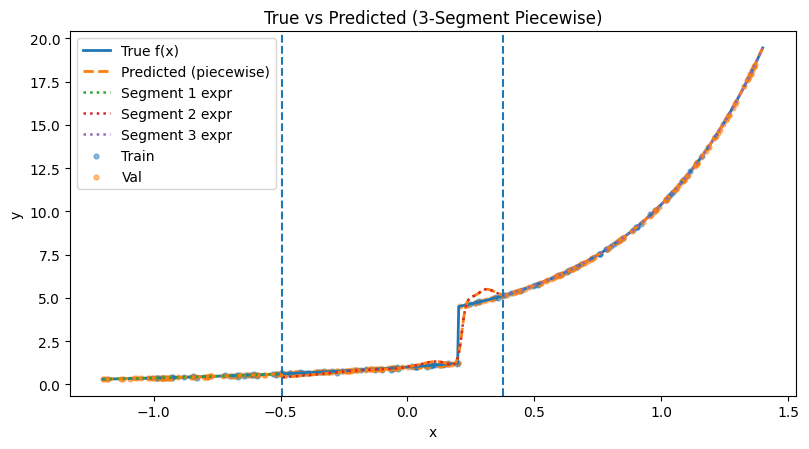

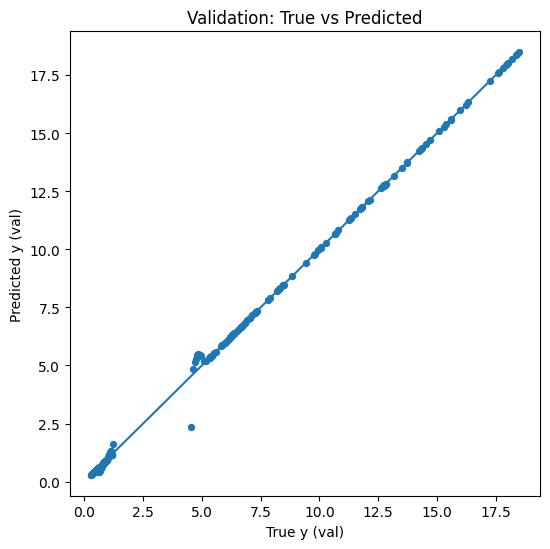

t1* = -0.4943451465994484  | t2* = 0.3754142052407379
f1(x): exp(x0)
f2(x): exp((x0 + (sin((sin((2.44549 + exp((x0 + (sin((x0 + (x0 + (sin((sin((2.44549 + exp((x0 + (sin((sin((x0 + (x0 * (x0 + sin(x0))))) + (sin(x...
f3(x): (3 + (exp(x0) * exp(x0)))


In [26]:
plot_piecewise3_result(best3, ground_truth, X_train, y_train, X_val, y_val)


# Serial two decision

In [27]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

def cart_split_threshold(X, y, mask=None, max_depth=1, min_leaf=5, random_state=0):
    """Depth-1 CART split on x[:,0]; returns threshold or None if no split."""
    if mask is None:
        Xs, ys = X, y
    else:
        Xs, ys = X[mask], y[mask]
    if Xs.shape[0] < 2*min_leaf:
        return None
    dt = DecisionTreeRegressor(max_depth=max_depth, min_samples_leaf=min_leaf, random_state=random_state)
    dt.fit(Xs, ys)
    thr = float(dt.tree_.threshold[0])
    return None if thr <= -1.5 else thr  # sklearn uses -2 when no split

def sequential_cart_two_boundaries(X, y, min_leaf=5, guard=1e-6):
    """
    1) First split t1 on all data (depth-1 CART).
    2) Choose worse side by SSE and split that side (depth-1 CART) -> t2.
    Returns ordered (t1, t2) with t1 < t2, plus which side was split second.
    """
    # first boundary
    t1 = cart_split_threshold(X, y, max_depth=1, min_leaf=min_leaf)
    if t1 is None:
        raise RuntimeError("CART couldn't find the first split; try lowering min_leaf.")

    x = X[:, 0]
    L = x <= t1
    R = ~L

    def side_sse(mask):
        if mask.sum() < 2: return np.inf
        mu = float(np.mean(y[mask]))
        return float(np.sum((y[mask] - mu)**2))

    sse_L, sse_R = side_sse(L), side_sse(R)

    if sse_L >= sse_R:
        # split LEFT side
        t2 = cart_split_threshold(X, y, mask=L, max_depth=1, min_leaf=min_leaf)
        if t2 is None or (t1 - t2) < guard:
            raise RuntimeError("Second split (left) failed; lower min_leaf or guard.")
        side = "left"
        t_low, t_high = t2, t1
    else:
        # split RIGHT side
        t2 = cart_split_threshold(X, y, mask=R, max_depth=1, min_leaf=min_leaf)
        if t2 is None or (t2 - t1) < guard:
            raise RuntimeError("Second split (right) failed; lower min_leaf or guard.")
        side = "right"
        t_low, t_high = t1, t2

    t1_out, t2_out = float(min(t_low, t_high)), float(max(t_low, t_high))
    return t1_out, t2_out, side


In [28]:
# Assumes these already exist from your earlier code:
#   evolve(X,y,...), eval_tree(tree, X), serialize(tree), rmse(y_true, y_pred)
# Optional: tree_size(tree)

LAMBDA_CONT = 1.0     # continuity weight (value match); tune as needed
BETA_SIZE   = 0.0     # no structure penalty for now
USE_SLOPE_CONT = False
FD_EPS = 1e-4

GP_KW = dict(pop_size=200, generations=80, max_depth=5)
SEEDS = [2, 7]        # a couple seeds per segment

def _has_tree_size():
    try:
        _ = tree_size  # noqa
        return True
    except NameError:
        return False

def _size_or_zero(t):
    return tree_size(t) if _has_tree_size() else 0

def _finite_diff_slope(tree, t):
    Xp = np.array([[t+FD_EPS]]); Xm = np.array([[t-FD_EPS]])
    return (float(eval_tree(tree, Xp)) - float(eval_tree(tree, Xm))) / (2*FD_EPS)

def _fit_segment_gp(X, y, mask, seeds=SEEDS, gp_kw=GP_KW):
    Xs, ys = X[mask], y[mask]
    if Xs.shape[0] < 5: return None, np.inf, None
    best, best_score, best_seed = None, np.inf, None
    for sd in seeds:
        try:  t, _, _ = evolve(Xs, ys, seed=sd, **gp_kw)
        except TypeError: t, _, _ = evolve(Xs, ys, rng_seed=sd, **gp_kw)
        pred = eval_tree(t, Xs)
        r = rmse(ys, pred)
        s = r + 1e-6 * _size_or_zero(t)  # tiny tie-breaker
        if s < best_score:
            best, best_score, best_seed = t, s, sd
    pred = eval_tree(best, Xs)
    return best, rmse(ys, pred), best_seed

def _objective_piecewise3(f1, f2, f3, t1, t2, X, y):
    x = X[:,0]
    S1 = x <= t1
    S2 = (x > t1) & (x <= t2)
    S3 = x > t2
    if (S1.sum()<3) or (S2.sum()<3) or (S3.sum()<3):
        return dict(obj=np.inf, rmse=np.inf, rmse1=np.inf, rmse2=np.inf, rmse3=np.inf,
                    gap1=np.inf, gap2=np.inf, size_pen=0.0)

    y1 = eval_tree(f1, X[S1]); r1 = rmse(y[S1], y1)
    y2 = eval_tree(f2, X[S2]); r2 = rmse(y[S2], y2)
    y3 = eval_tree(f3, X[S3]); r3 = rmse(y[S3], y3)

    N = float(len(y))
    piece_rmse = np.sqrt(((y[S1]-y1)**2).sum() + ((y[S2]-y2)**2).sum() + ((y[S3]-y3)**2).sum()) / np.sqrt(N)

    # continuity penalties (value match)
    f1_t1 = float(eval_tree(f1, np.array([[t1]])))
    f2_t1 = float(eval_tree(f2, np.array([[t1]])))
    f2_t2 = float(eval_tree(f2, np.array([[t2]])))
    f3_t2 = float(eval_tree(f3, np.array([[t2]])))
    gap1 = f1_t1 - f2_t1
    gap2 = f2_t2 - f3_t2
    cont_pen = LAMBDA_CONT * (gap1*gap1 + gap2*gap2)

    size_pen = BETA_SIZE * (_size_or_zero(f1) + _size_or_zero(f2) + _size_or_zero(f3))
    total = piece_rmse + cont_pen + size_pen
    return dict(obj=total, rmse=piece_rmse, rmse1=r1, rmse2=r2, rmse3=r3, gap1=gap1, gap2=gap2, size_pen=size_pen)

def fit_gp_after_sequential_cart(X, y, min_leaf=5):
    """
    1) Get (t1, t2) from sequential CART.
    2) Fit GP models on the 3 segments.
    3) Return dict with thresholds, trees, and metrics.
    """
    t1, t2, side = sequential_cart_two_boundaries(X, y, min_leaf=min_leaf)

    x = X[:,0]
    S1 = x <= t1
    S2 = (x > t1) & (x <= t2)
    S3 = x > t2

    f1, r1, s1 = _fit_segment_gp(X, y, S1)
    f2, r2, s2 = _fit_segment_gp(X, y, S2)
    f3, r3, s3 = _fit_segment_gp(X, y, S3)

    comp = _objective_piecewise3(f1, f2, f3, t1, t2, X, y)

    out = dict(
        t1=float(t1), t2=float(t2), side_split=side,
        f1=f1, f2=f2, f3=f3,
        metrics=comp
    )
    return out


In [29]:
def predict_piecewise3(f1, f2, f3, t1, t2, X):
    x = X[:,0]
    out = np.empty_like(x, dtype=float)
    S1 = x <= t1
    S2 = (x > t1) & (x <= t2)
    S3 = x > t2
    if S1.any(): out[S1] = eval_tree(f1, X[S1])
    if S2.any(): out[S2] = eval_tree(f2, X[S2])
    if S3.any(): out[S3] = eval_tree(f3, X[S3])
    return out

# === Usage (after you have X_train, y_train, and optionally X_val, y_val) ===
best_seq_gp = fit_gp_after_sequential_cart(X_train, y_train, min_leaf=8)

print("Boundaries (CART): t1* =", best_seq_gp["t1"], " t2* =", best_seq_gp["t2"],
      " | second split side:", best_seq_gp["side_split"])
print("f1:", serialize(best_seq_gp["f1"]))
print("f2:", serialize(best_seq_gp["f2"]))
print("f3:", serialize(best_seq_gp["f3"]))
print("Metrics:", best_seq_gp["metrics"])

# Optional: validation RMSE
yhat_val = predict_piecewise3(best_seq_gp["f1"], best_seq_gp["f2"], best_seq_gp["f3"],
                              best_seq_gp["t1"], best_seq_gp["t2"], X_val)
print("Val RMSE:", rmse(y_val, yhat_val))


/tmp/ipython-input-2481395598.py:92: RuntimeWarning: overflow encountered in exp
  return f(eval_tree(t[2], X))
/tmp/ipython-input-2481395598.py:92: RuntimeWarning: invalid value encountered in cos
  return f(eval_tree(t[2], X))
/tmp/ipython-input-2481395598.py:92: RuntimeWarning: invalid value encountered in sin
  return f(eval_tree(t[2], X))


Boundaries (CART): t1* = 0.21436158567667007  t2* = 0.8252783119678497  | second split side: right
f1: exp(x0)
f2: (3.52351 * exp(x0))
f3: (exp((x0 + x0)) + 3.00863)
Metrics: {'obj': np.float64(9.861684583474451), 'rmse': np.float64(0.05375684701246672), 'rmse1': 0.03309423647893691, 'rmse2': 0.09034678093715214, 'rmse3': 0.023573625480422366, 'gap1': -3.1268096569600434, 'gap2': -0.1760372278905784, 'size_pen': 0.0}
Val RMSE: 0.21498445019255966


/tmp/ipython-input-4028342128.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f1_t1 = float(eval_tree(f1, np.array([[t1]])))
/tmp/ipython-input-4028342128.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f2_t1 = float(eval_tree(f2, np.array([[t1]])))
/tmp/ipython-input-4028342128.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f2_t2 = float(eval_tree(f2, np.array([[t2]])))
/tmp/ipython-input-4028342128.py:62: DeprecationWarning: Conversion of an array

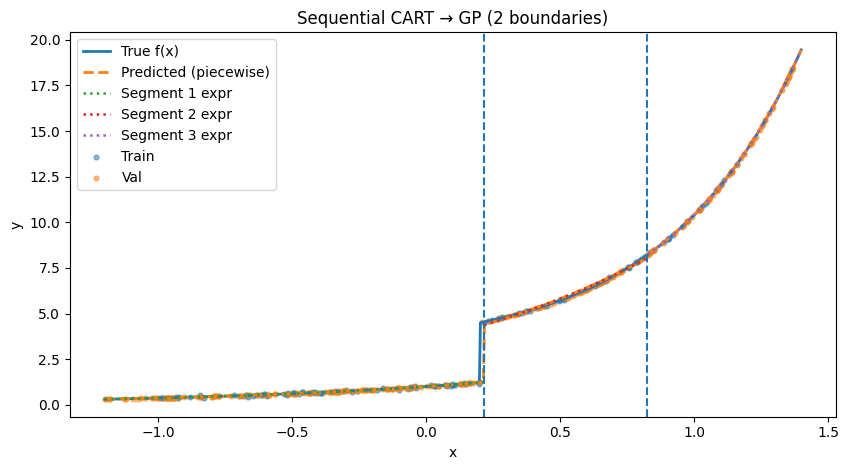

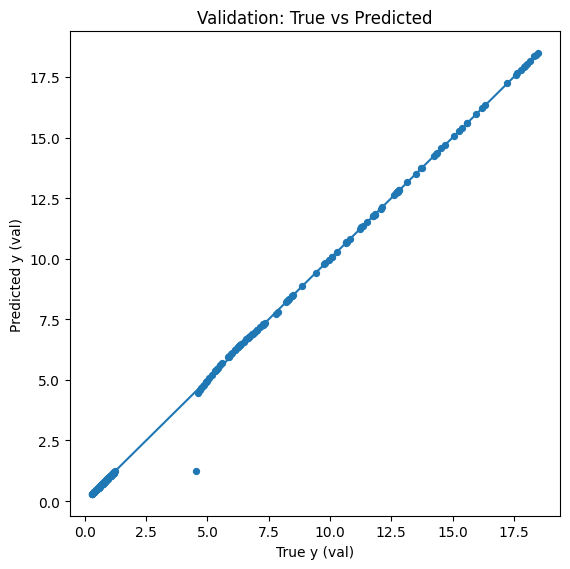

Boundaries (CART): t1* = 0.21436158567667007  | t2* = 0.8252783119678497 | second split: right
f1(x): exp(x0)
f2(x): (3.52351 * exp(x0))
f3(x): (exp((x0 + x0)) + 3.00863)


In [30]:
# --- Plot after sequential CART → GP (two boundaries, three segments) ---
# Requires:
#   best_seq_gp = fit_gp_after_sequential_cart(X_train, y_train, ...)
#   predict_piecewise3(...), eval_tree(), serialize()
#   (optional) ground_truth(x), X_val, y_val

import numpy as np
import matplotlib.pyplot as plt

def plot_seq_cart_gp(best_seq_gp,
                     ground_truth=None,
                     X_train=None, y_train=None,
                     X_val=None, y_val=None,
                     x_min=-1.2, x_max=1.4, n_points=700,
                     title="Sequential CART → GP (2 boundaries)"):
    t1 = float(best_seq_gp["t1"])
    t2 = float(best_seq_gp["t2"])
    f1, f2, f3 = best_seq_gp["f1"], best_seq_gp["f2"], best_seq_gp["f3"]

    # dense grid
    xs = np.linspace(x_min, x_max, n_points).reshape(-1, 1)
    xr = xs.ravel()

    # piecewise prediction
    y_pred = predict_piecewise3(f1, f2, f3, t1, t2, xs)

    # optional true curve
    y_true = ground_truth(xr) if ground_truth is not None else None

    # segment-wise explicit curves (for visualizing formulas)
    L1 = xr <= t1
    L2 = (xr > t1) & (xr <= t2)
    L3 = xr > t2
    y1_curve = np.full_like(xr, np.nan, dtype=float)
    y2_curve = np.full_like(xr, np.nan, dtype=float)
    y3_curve = np.full_like(xr, np.nan, dtype=float)
    if L1.any(): y1_curve[L1] = eval_tree(f1, xs[L1])
    if L2.any(): y2_curve[L2] = eval_tree(f2, xs[L2])
    if L3.any(): y3_curve[L3] = eval_tree(f3, xs[L3])

    # ---- Figure 1: function view ----
    plt.figure(figsize=(8.6, 4.8))
    if y_true is not None:
        plt.plot(xr, y_true, label="True f(x)", linewidth=2.0)
    plt.plot(xr, y_pred, "--", label="Predicted (piecewise)", linewidth=2.0)
    plt.plot(xr, y1_curve, ":", label="Segment 1 expr", linewidth=1.8)
    plt.plot(xr, y2_curve, ":", label="Segment 2 expr", linewidth=1.8)
    plt.plot(xr, y3_curve, ":", label="Segment 3 expr", linewidth=1.8)

    if X_train is not None and y_train is not None:
        plt.scatter(X_train[:,0], y_train, s=12, alpha=0.5, label="Train")
    if X_val is not None and y_val is not None:
        plt.scatter(X_val[:,0], y_val, s=12, alpha=0.5, label="Val")

    plt.axvline(t1, linestyle="--")
    plt.axvline(t2, linestyle="--")
    plt.xlabel("x"); plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---- Figure 2: Validation scatter ----
    if X_val is not None and y_val is not None:
        yhat_val = predict_piecewise3(f1, f2, f3, t1, t2, X_val)
        plt.figure(figsize=(5.8, 5.8))
        plt.scatter(y_val, yhat_val, s=18)
        mn = float(min(np.min(y_val), np.min(yhat_val)))
        mx = float(max(np.max(y_val), np.max(yhat_val)))
        plt.plot([mn, mx], [mn, mx])
        plt.xlabel("True y (val)"); plt.ylabel("Predicted y (val)")
        plt.title("Validation: True vs Predicted")
        plt.tight_layout()
        plt.show()

    # print concise equations
    def _short(s, n=160): return s if len(s) <= n else s[:n-3] + "..."
    print("Boundaries (CART): t1* =", t1, " | t2* =", t2, "| second split:", best_seq_gp.get("side_split"))
    print("f1(x):", _short(serialize(f1)))
    print("f2(x):", _short(serialize(f2)))
    print("f3(x):", _short(serialize(f3)))

# Usage:
plot_seq_cart_gp(best_seq_gp, ground_truth, X_train, y_train, X_val, y_val)


# 🧬 Dynamic Piecewise Genetic Algorithm (DPGA)

This notebook extends the sequential CART → GP framework to dynamically add decision boundaries.
Each iteration:
1. Proposes a new split (using CART) on the worst segment.
2. Fits GP models on all resulting subsegments.
3. Evaluates composite objective:
   \[
   J = \text{RMSE} + \lambda_c \sum (\Delta f)^2 + \gamma \, N_{\text{splits}}
   \]
4. Stops if objective no longer improves or max_splits reached.


🧩 Step 2 — Genetic Expression Utilities

In [31]:
OPS = ["+", "-", "*", "/", "sin", "cos", "exp", "log"]
MAX_DEPTH = 4

def random_tree(depth=0):
    if depth > MAX_DEPTH or random.random() < 0.3:
        return random.choice(["x", str(round(random.uniform(-2, 2), 2))])
    op = random.choice(OPS)
    if op in ["sin", "cos", "exp", "log"]:
        return (op, random_tree(depth + 1))
    else:
        return (op, random_tree(depth + 1), random_tree(depth + 1))

def eval_tree(t, X):
    """Evaluate tree for X shaped (N,) or (N,1)."""
    X = np.asarray(X).reshape(-1)
    if isinstance(t, str):
        return X if t == "x" else np.full_like(X, float(t))
    op = t[0]
    if op in ["+", "-", "*", "/"]:
        a, b = eval_tree(t[1], X), eval_tree(t[2], X)
        with np.errstate(divide="ignore", invalid="ignore"):
            if op == "+": return a + b
            if op == "-": return a - b
            if op == "*": return a * b
            return np.where(np.abs(b) < 1e-9, a, a / b)
    elif op == "sin": return np.sin(eval_tree(t[1], X))
    elif op == "cos": return np.cos(eval_tree(t[1], X))
    elif op == "exp": return np.exp(np.clip(eval_tree(t[1], X), -10, 10))
    elif op == "log": return np.log(np.abs(eval_tree(t[1], X)) + 1e-6)

def serialize(t):
    if isinstance(t, str): return t
    op = t[0]
    if op in ["+", "-", "*", "/"]:
        return f"({serialize(t[1])} {op} {serialize(t[2])})"
    else:
        return f"{op}({serialize(t[1])})"

def rmse(y_true, y_pred):
    return np.sqrt(np.nanmean((y_true.ravel() - y_pred.ravel())**2))

def mutate(t):
    if random.random() < 0.2:
        return random_tree()
    if isinstance(t, str):
        return random_tree() if random.random() < 0.1 else t
    op = t[0]
    if op in ["+", "-", "*", "/"]:
        return (op, mutate(t[1]), mutate(t[2]))
    else:
        return (op, mutate(t[1]))

def crossover(t1, t2):
    if random.random() < 0.5: return t2
    if isinstance(t1, str): return t2
    op = t1[0]
    if op in ["+", "-", "*", "/"]:
        return (op, crossover(t1[1], t2), crossover(t1[2], t2))
    else:
        return (op, crossover(t1[1], t2))

def evolve(X, y, pop_size=150, generations=60):
    X, y = X.reshape(-1, 1), y.ravel()
    pop = [random_tree() for _ in range(pop_size)]
    for _ in range(generations):
        scores = []
        for t in pop:
            try:
                s = rmse(y, eval_tree(t, X))
                if not np.isfinite(s): s = 1e6
            except Exception:
                s = 1e6
            scores.append(s)
        ranks = np.argsort(scores)
        top = [pop[i] for i in ranks[:pop_size//5]]
        next_pop = top.copy()
        while len(next_pop) < pop_size:
            p1, p2 = random.choice(top), random.choice(top)
            child = crossover(p1, p2)
            if random.random() < 0.3:
                child = mutate(child)
            next_pop.append(child)
        pop = next_pop
    best = min(pop, key=lambda t: rmse(y, eval_tree(t, X)))
    return best


✅ Step 3: CART Split and Dynamic GA

In [32]:
def cart_split_threshold(X, y, mask=None, min_leaf=5):
    if mask is not None:
        Xs, ys = X[mask], y[mask]
    else:
        Xs, ys = X, y
    if len(Xs) < 2*min_leaf:
        return None
    dt = DecisionTreeRegressor(max_depth=1, min_samples_leaf=min_leaf)
    dt.fit(Xs, ys)
    t = float(dt.tree_.threshold[0])
    return None if t <= -1.5 else t

def dynamic_gp(X, y, max_splits=3, min_leaf=5, λ=1.0, γ=0.05):
    """
    Dynamic piecewise genetic algorithm:
    sequentially adds CART boundaries, fits genetic models on segments,
    penalizes both discontinuity and number of splits.
    """
    X, y = np.asarray(X).reshape(-1, 1), np.asarray(y).ravel()
    f0 = evolve(X, y)
    best_trees, thresholds = [f0], []
    best_obj = rmse(y, eval_tree(f0, X))
    best_config = dict(trees=best_trees, thresholds=[], metrics=dict(obj=best_obj))

    print(f"Start Obj={best_obj:.4f}")

    for s in range(max_splits):
        x = X[:, 0]
        edges = [-np.inf] + thresholds + [np.inf]
        masks = [(x > edges[i]) & (x <= edges[i+1]) for i in range(len(edges)-1)]

        # find worst segment by RMSE
        seg_err = []
        for i, m in enumerate(masks):
            try:
                seg_err.append(rmse(y[m], eval_tree(best_trees[i], X[m])))
            except Exception:
                seg_err.append(np.inf)
        worst_i = int(np.argmax(seg_err))
        mask = masks[worst_i]

        # propose new split inside worst segment
        t_new = cart_split_threshold(X, y, mask=mask, min_leaf=min_leaf)
        if t_new is None:
            print("No valid split found; stopping.")
            break
        thresholds.append(float(t_new))
        thresholds.sort()

        # refit GPs for new segments
        edges = [-np.inf] + thresholds + [np.inf]
        trees = []
        for i in range(len(edges)-1):
            m = (x > edges[i]) & (x <= edges[i+1])
            if np.sum(m) < 3:
                # reuse previous best tree if too small
                trees.append(best_trees[min(i, len(best_trees)-1)])
            else:
                trees.append(evolve(X[m], y[m]))

        # evaluate objective
        preds = np.zeros_like(y)
        for i, m in enumerate([(x > edges[i]) & (x <= edges[i+1]) for i in range(len(edges)-1)]):
            preds[m] = eval_tree(trees[i], X[m])
        rm = rmse(y, preds)

        # continuity (safe scalar eval)
        cont = 0.0
        for i, t in enumerate(thresholds):
            if i < len(trees)-1:
                fL = float(np.ravel(eval_tree(trees[i], np.array([[t]])))[0])
                fR = float(np.ravel(eval_tree(trees[i+1], np.array([[t]])))[0])
                cont += (fL - fR)**2

        obj = rm + λ*cont + γ*len(thresholds)
        print(f"Split {s+1}: thresholds={thresholds}, Obj={obj:.4f}, RMSE={rm:.4f}")

        # accept if improves
        if obj < best_config["metrics"]["obj"]:
            best_config = dict(trees=trees.copy(),
                               thresholds=thresholds.copy(),
                               metrics=dict(obj=obj, rmse=rm, cont=cont))
        else:
            print("No improvement; stopping.")
            break

    return best_config


def predict_piecewise(model, X):
    """Predict safely, even if segment/tree counts mismatch."""
    X = np.asarray(X).reshape(-1, 1)
    x = X[:, 0]
    trees, thresholds = model["trees"], sorted(model["thresholds"])
    edges = [-np.inf] + thresholds + [np.inf]
    out = np.zeros_like(x)
    nseg = min(len(trees), len(edges) - 1)
    for i in range(nseg):
        m = (x > edges[i]) & (x <= edges[i+1])
        out[m] = eval_tree(trees[i], X[m])
    return out


def plot_dpga(model, X, y, ground_truth=None):
    """Visualize learned piecewise model with true vs predicted."""
    X = np.asarray(X).reshape(-1, 1)
    xs = np.linspace(np.min(X), np.max(X), 500).reshape(-1, 1)
    yp = predict_piecewise(model, xs)
    plt.figure(figsize=(8, 4))
    if ground_truth is not None:
        plt.plot(xs, ground_truth(xs.ravel()), label="True f(x)", lw=2)
    plt.plot(xs, yp, "--", label="DPGA Pred", lw=2)
    for t in model["thresholds"]:
        plt.axvline(t, ls="--", color="gray")
    plt.scatter(X, y, s=10, color="k", alpha=0.5)
    plt.legend(); plt.xlabel("x"); plt.ylabel("y")
    plt.title("Dynamic Piecewise Genetic Algorithm (DPGA)")
    plt.tight_layout(); plt.show()



✅ Step 5: Run Using Your Existing Train/Val Splits

Start Obj=0.7342
Split 1: thresholds=[0.21436158567667007], Obj=8.9112, RMSE=0.1737
No improvement; stopping.
Best thresholds: []
Metrics: {'obj': np.float64(0.7342474897805139)}
Validation RMSE: 0.7358162350142201


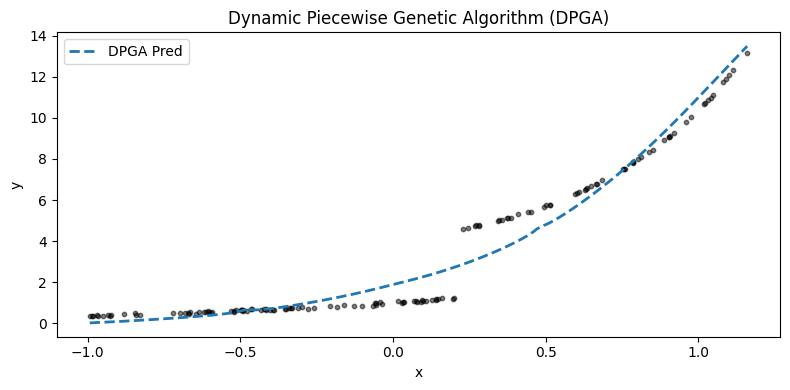

In [33]:
# Run on your existing X_train, y_train
best_dyn = dynamic_gp(X_train, y_train, max_splits=3, min_leaf=8, λ=1.0, γ=0.05)

print("Best thresholds:", best_dyn["thresholds"])
print("Metrics:", best_dyn["metrics"])

# Validate
yhat_val = predict_piecewise(best_dyn, X_val)
print("Validation RMSE:", rmse(y_val, yhat_val))

# Plot results
plot_dpga(best_dyn, X_train, y_train)


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# ──────────────────────────────
#  Utility Functions
# ──────────────────────────────
def cart_split_threshold(X, y, mask=None, min_leaf=5):
    if mask is not None:
        Xs, ys = X[mask], y[mask]
    else:
        Xs, ys = X, y
    if len(Xs) < 2*min_leaf:
        return None
    dt = DecisionTreeRegressor(max_depth=1, min_samples_leaf=min_leaf)
    dt.fit(Xs, ys)
    t = float(dt.tree_.threshold[0])
    return None if t <= -1.5 else t

def safe_scalar(z):  # helper for continuity penalty
    return float(np.ravel(z)[0]) if np.ndim(z) > 0 else float(z)

# ──────────────────────────────
#  Core Evaluation Function
# ──────────────────────────────
def evaluate_fixed_splits(X, y, n_splits=0, λ=1.0, γ=0.05, min_leaf=5):
    """
    Fit DPGA with exactly n_splits boundaries (sequential CART proposals),
    using evolve() for symbolic fits. Returns thresholds, trees, and metrics.
    """
    X, y = np.asarray(X).reshape(-1, 1), np.asarray(y).ravel()

    # --- Step 1: find thresholds ---
    thresholds = []
    x = X[:, 0]
    if n_splits > 0:
        # sequential CART on worst segments
        f0 = evolve(X, y)
        trees = [f0]
        for s in range(n_splits):
            edges = [-np.inf] + thresholds + [np.inf]
            masks = [(x > edges[i]) & (x <= edges[i+1]) for i in range(len(edges)-1)]
            seg_err = [rmse(y[m], eval_tree(trees[i], X[m])) for i, m in enumerate(masks)]
            worst_i = int(np.argmax(seg_err))
            m = masks[worst_i]
            t_new = cart_split_threshold(X, y, mask=m, min_leaf=min_leaf)
            if t_new is None:
                break
            thresholds.append(float(t_new))
            thresholds.sort()
    else:
        trees = []

    # --- Step 2: fit segment models ---
    edges = [-np.inf] + thresholds + [np.inf]
    trees = []
    for i in range(len(edges)-1):
        m = (x > edges[i]) & (x <= edges[i+1])
        trees.append(evolve(X[m], y[m]))

    # --- Step 3: evaluate objective ---
    preds = np.zeros_like(y)
    for i, m in enumerate([(x > edges[i]) & (x <= edges[i+1]) for i in range(len(edges)-1)]):
        preds[m] = eval_tree(trees[i], X[m])
    rm = rmse(y, preds)

    cont = 0.0
    for i, t in enumerate(thresholds):
        if i < len(trees)-1:
            fL = safe_scalar(eval_tree(trees[i], np.array([[t]])))
            fR = safe_scalar(eval_tree(trees[i+1], np.array([[t]])))
            cont += (fL - fR)**2

    obj = rm + λ*cont + γ*len(thresholds)
    return dict(trees=trees, thresholds=thresholds,
                metrics=dict(rmse=rm, cont=cont, obj=obj))


# ──────────────────────────────
#  Sweep over 0–3 splits
# ──────────────────────────────
results = []
for n in range(4):  # 0, 1, 2, 3 splits
    print(f"\n=== Fitting with {n} boundary(ies) ===")
    res = evaluate_fixed_splits(X_train, y_train,
                                n_splits=n, λ=1.0, γ=0.05, min_leaf=8)
    print(f"RMSE={res['metrics']['rmse']:.5f}, "
          f"Cont={res['metrics']['cont']:.5f}, "
          f"Obj={res['metrics']['obj']:.5f}, "
          f"Thresholds={res['thresholds']}")
    results.append(res)

# ──────────────────────────────
#  Plot objective vs. #splits
# ──────────────────────────────
plt.figure(figsize=(6,4))
splits = [len(r["thresholds"]) for r in results]
objs   = [r["metrics"]["obj"] for r in results]
plt.plot(splits, objs, "o-", lw=2)
plt.xlabel("# Splits"); plt.ylabel("Objective")
plt.title("DPGA Objective vs Number of Splits")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# ───────────────────────────────────────────────────────────
#  Plot best model among 0–3 splits
# ──────────────────────────────────────────────────────────
best_res = min(results, key=lambda r: r["metrics"]["obj"])
print("\nBest model has", len(best_res["thresholds"]), "splits -> thresholds:", best_res["thresholds"])

xs = np.linspace(np.min(X_train), np.max(X_train), 500).reshape(-1, 1)
yp = predict_piecewise(best_res, xs)
plt.figure(figsize=(8,4))
plt.scatter(X_train, y_train, s=10, alpha=0.5, color="k")
plt.plot(xs, yp, "--", lw=2, label="DPGA Pred")
for t in best_res["thresholds"]:
    plt.axvline(t, ls="--", color="gray")
plt.legend(); plt.title("Best DPGA Model Across Split Depths")
plt.tight_layout()
plt.show()



=== Fitting with 0 boundary(ies) ===
RMSE=1.19899, Cont=0.00000, Obj=1.19899, Thresholds=[]

=== Fitting with 1 boundary(ies) ===
RMSE=0.11780, Cont=9.18131, Obj=9.34911, Thresholds=[0.21436158567667007]

=== Fitting with 2 boundary(ies) ===


KeyboardInterrupt: 

# Comments




*   Developed a genetic algorithm integrated with a decision-tree–based model to explore how algorithmic discovery can modify and uncover underlying physical relationships.

*   Demonstrated that the approach can adapt to changing physics laws and autonomously identify new governing relationships.


*  Showed that introducing additional decision boundaries does not necessarily degrade performance — as long as the boundaries are sequential rather than parallel, maintaining interpretability and stability.

*   Attempted a dynamic version where each new boundary incrementally increases model complexity while reducing performance score; implementation remains incomplete.

*   Future direction: instead of building everything from scratch, leverage an existing library and focus on modifying the genetic algorithm component for improved efficiency.

*   Conceptual insight: the decision-based model can be viewed as a combination of step (or Dirac delta) function over the symbolic expression — each capturing a discrete physical regime.



*   This opens the possibility to replace step functions with smoother functional forms to represent more complex physical phenomena.

*   As Sergei mentioned: the approach shares similarities with neural networks, where simple architectures but complex activation functions can approximate rich physics


*  Just thinking about it, the above approach is also analogous to a Fourier series, where weights act as coefficients capturing the system’s structure and the functions are purely sine and cosine based



*   Also want  to explore representing physics not as explicit functions but as functionals (mappings between functions) — enabling a higher-order description of composite or emergent behaviors.

*   Next steps involve assessing whether such a functional formulation is computationally meaningful and how it might be implemented within the genetic algorithm framework.























#